# Hasil Pemilu 2024 dan sentimen post X tentang Golkar

Notebook ini punya dua bagian yang sengaja dipisah.

Bagian pertama (bagian 1–13) membaca hasil resmi suara partai untuk DPR RI pada Pemilu 2024. Fokusnya adalah posisi Partai Golongan Karya (Golkar) di 38 provinsi.

Bagian kedua (bagian 14 dan seterusnya) membaca post X yang sudah tersimpan di proyek. Post itu tidak dikumpulkan ulang dari X. Label sentimen pada bagian ini adalah prediksi model, bukan label manusia yang sudah diverifikasi.

Dua bagian itu mengukur hal yang berbeda.

- Perolehan suara menunjukkan hasil Pemilu menurut keputusan KPU.
- Sentimen hanya menggambarkan post yang berhasil dikumpulkan dalam berkas ini, lalu diberi label oleh model.

Keduanya tidak digabung menjadi satu kesimpulan. Jumlah post bukan jumlah suara. Sentimen pada post ini bukan sikap seluruh pemilih.

## 1. Latar belakang singkat

Pemilu 2024 memilih anggota DPR RI di seluruh provinsi. Setiap pemilih yang suaranya sah untuk DPR RI tercatat pada salah satu partai peserta. Notebook ini menyusun kembali angka tingkat provinsi agar pola antarprovinsi bisa dibaca, lalu memeriksa apakah jumlahnya sama dengan hasil nasional.

Golkar adalah salah satu partai peserta, bernomor urut 4. Notebook ini menempatkan Golkar di antara partai lain. Posisi Golkar dilaporkan apa adanya: di provinsi tertentu Golkar suara terbanyak, di provinsi lain tidak.

Tidak ada bagian notebook ini yang menjelaskan *mengapa* suatu partai unggul. Sebab-akibat butuh data lain yang tidak ada di berkas ini, misalnya daftar pemilih, calon, atau isi percakapan publik.

## 2. Data, sumber, dan batasan

Berkas yang dipakai:

| Berkas | Peran |
| --- | --- |
| `datasets/kpu_suara_partai_dprri_per_provinsi_2024.csv` | Suara tiap partai di tiap provinsi. Ini tabel utama. |
| `datasets/kpu_ringkasan_partai_terbanyak_per_provinsi_2024.csv` | Ringkasan partai peringkat pertama dan kedua. Dipakai untuk pemeriksaan silang. |
| `datasets/kpu_suara_nasional_pemilu_2024.csv` | Jumlah nasional tiap partai menurut Keputusan KPU 1204 Tahun 2024. Dipakai hanya untuk mencocokkan hasil penjumlahan. |

Sumber resmi yang dirujuk berkas:

- Keputusan KPU Nomor 1050 Tahun 2024 Lampiran II, untuk angka provinsi.
- Keputusan KPU Nomor 1204 Tahun 2024, untuk angka nasional dan status ambang batas 4 persen.

**Cara membaca persentase provinsi.** Kolom `persentase_dari_suara_sah_provinsi` sudah ada di data. Penyebutnya adalah `total_suara_sah_partai_dpr_ri_provinsi`: jumlah suara sah seluruh partai untuk DPR RI di provinsi itu. Bukan jumlah pemilih terdaftar (DPT). Bukan pula jumlah seluruh orang yang datang ke TPS. CSV ini tidak memuat kedua angka itu.

**Aceh.** Di Aceh, CSV ini mencakup partai nasional untuk DPR RI. Partai lokal Aceh dalam pemilihan DPRA/DPRK tidak termasuk.

**Yang tidak dilakukan.** Angka sumber tidak dibulatkan ulang untuk “dirapikan”, tidak diganti, dan tidak dilengkapi dengan perkiraan. Jika pemeriksaan menemukan selisih, selisih itu dilaporkan dan penghitungan berhenti.

## 3. Menyiapkan hitungan

Sel berikut hanya memuat data dan menyiapkan folder keluaran. Tidak ada angka yang diubah.

Jalankan sel dari atas ke bawah. Folder `datasets` dicari di folder kerja, atau satu tingkat di atasnya bila notebook dibuka dari folder `notebooks`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "figure.dpi": 120,
})

cwd = Path.cwd()
if (cwd / "datasets").exists():
    ROOT = cwd
elif (cwd.parent / "datasets").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Folder datasets tidak ditemukan. Jalankan notebook dari folder proyek atau dari folder notebooks."
    )

DATA = ROOT / "datasets"
OUT = ROOT / "outputs"
GAMBAR = OUT / "gambar"
OUT.mkdir(parents=True, exist_ok=True)
GAMBAR.mkdir(parents=True, exist_ok=True)

NAMA_GOLKAR = "Partai Golongan Karya"
SUMBER_PROVINSI = "Keputusan KPU Nomor 1050 Tahun 2024 Lampiran II"
SUMBER_NASIONAL = "Keputusan KPU Nomor 1204 Tahun 2024"
CATATAN_GAMBAR = (
    f"Sumber: {SUMBER_PROVINSI}. Satuan: suara sah partai untuk DPR RI.\n"
    "Persentase memakai penyebut total suara sah partai DPR RI di provinsi yang sama, "
    "bukan DPT dan bukan jumlah orang yang datang ke TPS."
)

SINGKATAN = {
    "Partai Kebangkitan Bangsa": "PKB",
    "Partai Gerakan Indonesia Raya": "Gerindra",
    "Partai Demokrasi Indonesia Perjuangan": "PDI-P",
    "Partai Golongan Karya": "Golkar",
    "Partai NasDem": "NasDem",
    "Partai Buruh": "Buruh",
    "Partai Gelombang Rakyat Indonesia": "Gelora",
    "Partai Keadilan Sejahtera": "PKS",
    "Partai Kebangkitan Nusantara": "PKN",
    "Partai Hati Nurani Rakyat": "Hanura",
    "Partai Garda Republik Indonesia": "Garuda",
    "Partai Amanat Nasional": "PAN",
    "Partai Bulan Bintang": "PBB",
    "Partai Demokrat": "Demokrat",
    "Partai Solidaritas Indonesia": "PSI",
    "Partai PERINDO": "Perindo",
    "Partai Persatuan Pembangunan": "PPP",
    "Partai Ummat": "Ummat",
}

# Warna hanya pembeda visual. Bukan penilaian terhadap partai.
WARNA_PARTAI = {
    "Partai Golongan Karya": "#0072B2",
    "Partai Demokrasi Indonesia Perjuangan": "#D55E00",
    "Partai Gerakan Indonesia Raya": "#009E73",
    "Partai NasDem": "#CC79A7",
    "Partai Keadilan Sejahtera": "#E69F00",
    "Partai Kebangkitan Bangsa": "#56B4E9",
    "Partai Amanat Nasional": "#332288",
}


def fmt_suara(nilai):
    return f"{int(nilai):,}".replace(",", ".")


def fmt_persen(nilai, angka=2):
    """Dua desimal untuk kalimat dan label grafik. Angka 5 dibulatkan ke atas.

    Titik awalnya adalah kolom sumber yang sudah empat desimal, misalnya 16,3250
    menjadi 16,33. Tabel tetap menampilkan empat desimal.
    """
    from decimal import Decimal, ROUND_HALF_UP

    empat_desimal = Decimal(str(round(float(nilai), 4)))
    bulat = empat_desimal.quantize(Decimal(10) ** -angka, rounding=ROUND_HALF_UP)
    return f"{bulat:.{angka}f}".replace(".", ",") + "%"


def fmt_persen_sumber(nilai):
    """Empat angka di belakang koma, sama seperti kolom persentase pada CSV."""
    return f"{float(nilai):.4f}".replace(".", ",") + "%"


def simpan_gambar(fig, nama):
    jalur = GAMBAR / nama
    fig.savefig(jalur, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Gambar disimpan: {jalur.relative_to(ROOT)}")


print(f"Folder proyek: {ROOT}")

Folder proyek: C:\Users\widya\Documents\Personal Project\Sentimen Analisis Golkar


In [2]:
detail = pd.read_csv(DATA / "kpu_suara_partai_dprri_per_provinsi_2024.csv")
ringkasan = pd.read_csv(DATA / "kpu_ringkasan_partai_terbanyak_per_provinsi_2024.csv")
nasional = pd.read_csv(DATA / "kpu_suara_nasional_pemilu_2024.csv")

urutan_provinsi = detail["provinsi"].drop_duplicates().tolist()

print(f"Baris tabel detail: {fmt_suara(len(detail))}")
print(f"Baris ringkasan provinsi: {len(ringkasan)}")
print(f"Baris hasil nasional: {len(nasional)}")
print(f"Sumber provinsi pada berkas: {detail['sumber_keputusan'].unique().tolist()}")
print(f"Sumber nasional pada berkas: {nasional['keputusan_kpu'].unique().tolist()}")

Baris tabel detail: 684
Baris ringkasan provinsi: 38
Baris hasil nasional: 18
Sumber provinsi pada berkas: ['KPU 1050 Tahun 2024 Lampiran II']
Sumber nasional pada berkas: ['KPU 1204 Tahun 2024']


## 4. Pemeriksaan data

Pemeriksaan dilakukan sebelum pola apa pun ditafsirkan. Ada dua jenis hasil.

- **Lulus** berarti angka sumber saling cocok. Tidak ada perbaikan.
- **Catatan** berarti ada hal yang perlu dibaca, tetapi bukan selisih suara. Contohnya pembulatan persentase.
- **Tidak lulus** menghentikan notebook. Angka sumber tidak diganti secara diam-diam.

Yang diperiksa:

1. Tabel detail berisi 38 provinsi, dan setiap provinsi berisi 18 partai.
2. Jumlah suara 18 partai di tiap provinsi sama dengan `total_suara_sah_partai_dpr_ri_provinsi`.
3. Jumlah suara tiap partai di seluruh provinsi sama dengan `suara_sah_nasional` pada berkas Keputusan KPU 1204 Tahun 2024.
4. Persentase provinsi sama dengan suara partai dibagi total suara sah partai di provinsi itu, dibulatkan 4 angka di belakang koma.
5. Peringkat 1 sampai 18 unik, dan suara tidak naik ketika peringkat membesar.
6. Ringkasan partai terbanyak cocok dengan tabel detail.

In [3]:
laporan = []
gagal = []


def catat(nama, lulus, keterangan, jenis="pemeriksaan"):
    status = "Lulus" if lulus else "Tidak lulus"
    laporan.append({"pemeriksaan": nama, "status": status, "keterangan": keterangan})
    if not lulus and jenis == "pemeriksaan":
        gagal.append(f"{nama}: {keterangan}")


n_provinsi = detail["provinsi"].nunique()
catat(
    "Jumlah provinsi",
    n_provinsi == 38,
    f"Ditemukan {n_provinsi} provinsi. Target pemeriksaan: 38.",
)

jumlah_partai = detail.groupby("provinsi").size()
provinsi_bukan_18 = jumlah_partai[jumlah_partai != 18]
catat(
    "18 partai di setiap provinsi",
    provinsi_bukan_18.empty and len(detail) == 38 * 18,
    "Semua provinsi memiliki 18 baris partai."
    if provinsi_bukan_18.empty
    else f"Penyimpangan: {provinsi_bukan_18.to_dict()}",
)

kunci_detail = set(zip(detail["nomor_partai"], detail["nama_partai"]))
kunci_nasional = set(zip(nasional["nomor_partai"], nasional["nama_partai"]))
catat(
    "Daftar partai sama dengan berkas nasional",
    kunci_detail == kunci_nasional,
    "18 pasangan nomor dan nama partai sama."
    if kunci_detail == kunci_nasional
    else f"Hanya di detail: {kunci_detail - kunci_nasional}. Hanya di nasional: {kunci_nasional - kunci_detail}.",
)

total_per_provinsi = (
    detail.groupby("provinsi", sort=False)
    .agg(
        jumlah_suara=("suara_sah_partai_dpr_ri", "sum"),
        total_tertulis=("total_suara_sah_partai_dpr_ri_provinsi", "first"),
        ragam_total=("total_suara_sah_partai_dpr_ri_provinsi", "nunique"),
    )
)
selisih_total = total_per_provinsi[total_per_provinsi["jumlah_suara"] != total_per_provinsi["total_tertulis"]]
total_berubah = total_per_provinsi[total_per_provinsi["ragam_total"] != 1]
catat(
    "Jumlah 18 partai sama dengan total provinsi",
    selisih_total.empty and total_berubah.empty,
    "Cocok di seluruh provinsi."
    if selisih_total.empty and total_berubah.empty
    else f"Selisih pada: {selisih_total.index.tolist()}. Total tidak konstan: {total_berubah.index.tolist()}.",
)

jumlah_nasional_dari_provinsi = (
    detail.groupby(["nomor_partai", "nama_partai"], as_index=False)["suara_sah_partai_dpr_ri"].sum()
)
cocok_nasional = jumlah_nasional_dari_provinsi.merge(
    nasional[["nomor_partai", "nama_partai", "suara_sah_nasional", "total_suara_sah_nasional"]],
    on=["nomor_partai", "nama_partai"],
    how="outer",
    indicator=True,
)
cocok_nasional["selisih"] = cocok_nasional["suara_sah_partai_dpr_ri"] - cocok_nasional["suara_sah_nasional"]
baris_nasional_selisih = cocok_nasional[
    cocok_nasional["_merge"].ne("both") | cocok_nasional["selisih"].fillna(1).ne(0)
]
total_suara_nasional = int(nasional["total_suara_sah_nasional"].iloc[0])
jumlah_semua_suara = int(detail["suara_sah_partai_dpr_ri"].sum())
catat(
    "Jumlah nasional tiap partai sama dengan KPU 1204",
    baris_nasional_selisih.empty and jumlah_semua_suara == total_suara_nasional,
    (
        f"Jumlah seluruh suara provinsi {fmt_suara(jumlah_semua_suara)} "
        f"sama dengan total nasional {fmt_suara(total_suara_nasional)}, dan tiap partai cocok."
    )
    if baris_nasional_selisih.empty and jumlah_semua_suara == total_suara_nasional
    else baris_nasional_selisih[["nama_partai", "suara_sah_partai_dpr_ri", "suara_sah_nasional", "selisih"]].to_string(index=False),
)

persen_hitung = (
    detail["suara_sah_partai_dpr_ri"] / detail["total_suara_sah_partai_dpr_ri_provinsi"] * 100
).round(4)
selisih_persen = (persen_hitung - detail["persentase_dari_suara_sah_provinsi"]).abs()
catat(
    "Persentase provinsi sesuai pembagian dan pembulatan 4 desimal",
    bool((selisih_persen < 0.00005).all()),
    (
        "Kolom persentase sama dengan suara partai dibagi total suara sah partai DPR RI "
        "di provinsi itu, lalu dibulatkan 4 angka di belakang koma."
    )
    if (selisih_persen < 0.00005).all()
    else f"Selisih terbesar: {selisih_persen.max():.6f}",
)

jumlah_persen = detail.groupby("provinsi")["persentase_dari_suara_sah_provinsi"].sum()
laporan.append({
    "pemeriksaan": "Jumlah persentase per provinsi",
    "status": "Catatan",
    "keterangan": (
        f"Jumlah 18 persentase yang sudah dibulatkan berkisar {jumlah_persen.min():.4f} "
        f"sampai {jumlah_persen.max():.4f}. Ini sisa pembulatan tiap baris, bukan selisih suara. "
        f"{int((jumlah_persen.round(4) != 100).sum())} provinsi tidak tepat 100,0000 setelah pembulatan."
    ),
})

masalah_peringkat = []
for provinsi, bagian in detail.groupby("provinsi"):
    peringkat = sorted(bagian["peringkat_suara_di_provinsi"].tolist())
    if peringkat != list(range(1, 19)):
        masalah_peringkat.append(provinsi)
        continue
    urut = bagian.sort_values("peringkat_suara_di_provinsi")
    suara_urut = urut["suara_sah_partai_dpr_ri"].tolist()
    if any(suara_urut[i] < suara_urut[i + 1] for i in range(len(suara_urut) - 1)):
        masalah_peringkat.append(provinsi)
catat(
    "Peringkat 1–18 konsisten dengan urutan suara",
    not masalah_peringkat,
    "Tidak ada suara seri, dan suara tidak naik ketika peringkat membesar."
    if not masalah_peringkat
    else f"Periksa: {masalah_peringkat}",
)

pemenang_detail = (
    detail.loc[detail["peringkat_suara_di_provinsi"] == 1, [
        "provinsi", "nama_partai", "suara_sah_partai_dpr_ri", "persentase_dari_suara_sah_provinsi",
        "partai_suara_terbanyak", "suara_partai_terbanyak",
    ]]
)
pemenang_konsisten = (
    (pemenang_detail["nama_partai"] == pemenang_detail["partai_suara_terbanyak"])
    & (pemenang_detail["suara_sah_partai_dpr_ri"] == pemenang_detail["suara_partai_terbanyak"])
)
catat(
    "Kolom partai terbanyak di tabel detail konsisten",
    bool(pemenang_konsisten.all()) and pemenang_detail["partai_suara_terbanyak"].groupby(detail.loc[detail["peringkat_suara_di_provinsi"] == 1, "provinsi"]).nunique().eq(1).all(),
    "Di setiap provinsi, partai peringkat 1 sama dengan kolom partai_suara_terbanyak."
    if bool(pemenang_konsisten.all())
    else "Ada baris peringkat 1 yang tidak sama dengan kolom partai terbanyak.",
)

peringkat_dua = detail.loc[
    detail["peringkat_suara_di_provinsi"] == 2,
    ["provinsi", "nama_partai", "suara_sah_partai_dpr_ri"],
]
silang = ringkasan.merge(
    pemenang_detail[["provinsi", "nama_partai", "suara_sah_partai_dpr_ri", "persentase_dari_suara_sah_provinsi"]],
    on="provinsi",
    how="outer",
    indicator="gabung_pemenang",
).merge(
    peringkat_dua,
    on="provinsi",
    how="outer",
    suffixes=("", "_peringkat_2"),
)
silang = silang.merge(
    total_per_provinsi["total_tertulis"].rename("total_dari_detail"),
    left_on="provinsi",
    right_index=True,
    how="left",
)
masalah_silang = []
if set(ringkasan["provinsi"]) != set(detail["provinsi"]):
    masalah_silang.append("daftar provinsi ringkasan berbeda")
if not (silang["total_suara_sah_partai_dpr_ri"] == silang["total_dari_detail"]).all():
    masalah_silang.append("total suara provinsi")
if not (silang["partai_dengan_suara_terbanyak"] == silang["nama_partai"]).all():
    masalah_silang.append("nama partai peringkat 1")
if not (silang["suara_partai_terbanyak"] == silang["suara_sah_partai_dpr_ri"]).all():
    masalah_silang.append("suara peringkat 1")
if not (silang["persentase_suara_partai_terbanyak"] - silang["persentase_dari_suara_sah_provinsi"]).abs().lt(0.00005).all():
    masalah_silang.append("persentase peringkat 1")
if not (silang["peringkat_kedua"] == silang["nama_partai_peringkat_2"]).all():
    masalah_silang.append("nama peringkat 2")
if not (silang["suara_partai_peringkat_kedua"] == silang["suara_sah_partai_dpr_ri_peringkat_2"]).all():
    masalah_silang.append("suara peringkat 2")
if not (silang["selisih_suara_1_dan_2"] == silang["suara_sah_partai_dpr_ri"] - silang["suara_sah_partai_dpr_ri_peringkat_2"]).all():
    masalah_silang.append("selisih peringkat 1 dan 2")
persen_nasional_hitung = (silang["total_suara_sah_partai_dpr_ri"] / total_suara_nasional * 100).round(4)
if not (silang["persentase_dari_total_nasional"] - persen_nasional_hitung).abs().lt(0.00005).all():
    masalah_silang.append("persentase provinsi terhadap total nasional")
catat(
    "Ringkasan partai terbanyak cocok dengan tabel detail",
    not masalah_silang,
    "Cocok, termasuk selisih suara peringkat 1 dan 2."
    if not masalah_silang
    else "Tidak cocok pada: " + ", ".join(masalah_silang) + ".",
)

tabel_laporan = pd.DataFrame(laporan)
display(tabel_laporan)

if gagal:
    raise AssertionError(
        "Pemeriksaan tidak lulus. Angka sumber tidak diubah.\n" + "\n".join(gagal)
    )

print("Pemeriksaan jumlah suara lulus. Angka sumber tidak diubah.")
print(
    "Catatan pembulatan: jumlah persentase yang sudah dibulatkan tidak selalu tepat 100. "
    "Jumlah suaranya tetap cocok."
)

,pemeriksaan,status,keterangan
0,Jumlah provinsi,Lulus,Ditemukan 38 provinsi. Target pemeriksaan: 38.
1,18 partai di setiap provinsi,Lulus,Semua provinsi memiliki 18 baris partai.
2,Daftar partai sama dengan berkas nasional,Lulus,18 pasangan nomor dan nama partai sama.
3,Jumlah 18 partai sama dengan total provinsi,Lulus,Cocok di seluruh provinsi.
4,Jumlah nasional tiap partai sama dengan KPU 1204,Lulus,Jumlah seluruh suara provinsi 151.793.293 sama...
5,Persentase provinsi sesuai pembagian dan pembu...,Lulus,Kolom persentase sama dengan suara partai diba...
6,Jumlah persentase per provinsi,Catatan,Jumlah 18 persentase yang sudah dibulatkan ber...
7,Peringkat 1–18 konsisten dengan urutan suara,Lulus,"Tidak ada suara seri, dan suara tidak naik ket..."
8,Kolom partai terbanyak di tabel detail konsisten,Lulus,"Di setiap provinsi, partai peringkat 1 sama de..."
9,Ringkasan partai terbanyak cocok dengan tabel ...,Lulus,"Cocok, termasuk selisih suara peringkat 1 dan 2."


Pemeriksaan jumlah suara lulus. Angka sumber tidak diubah.
Catatan pembulatan: jumlah persentase yang sudah dibulatkan tidak selalu tepat 100. Jumlah suaranya tetap cocok.


## 5. Metode

Semua hitungan memakai seluruh baris. Tidak ada sampel dan tidak ada pembobotan ulang.

**Peringkat di provinsi** diambil dari kolom `peringkat_suara_di_provinsi`. Peringkat 1 adalah suara terbanyak di provinsi itu. Pemeriksaan di atas memastikan urutan ini mengikuti jumlah suara. Tidak ada dua partai dengan jumlah suara yang sama, jadi tidak ada suara seri yang perlu dipecah.

**Persentase di provinsi** diambil dari kolom yang sudah tersedia, bukan dihitung ulang untuk tabel hasil. Penyebutnya total suara sah partai DPR RI di provinsi tersebut. Pemeriksaan menunjukkan kolom itu sama dengan:

`suara partai / total suara sah partai DPR RI provinsi × 100`, dibulatkan 4 angka di belakang koma.

**Persentase nasional** tidak tersedia sebagai kolom pada tabel provinsi. Angka ini dihitung di notebook:

`suara partai di seluruh provinsi / 151.793.293 × 100`.

Pembulatan ke 2 angka di belakang koma hanya dipakai pada kalimat dan label grafik. Aturannya: angka 5 dibulatkan ke atas, dihitung dari nilai empat desimal pada kolom sumber. Contoh: 16,3250 persen di Jawa Barat ditulis 16,33 persen. Tabel tetap menampilkan 16,3250.

**Selisih Golkar** mengikuti posisi Golkar di provinsi itu.

- Jika Golkar peringkat 1, selisih = suara Golkar dikurangi suara partai peringkat 2. Nilai positif berarti Golkar memimpin.
- Jika Golkar bukan peringkat 1, selisih = suara Golkar dikurangi suara partai peringkat 1. Nilai negatif berarti Golkar tertinggal.

**Pengelompokan enam provinsi di Pulau Jawa** (DKI Jakarta, Jawa Barat, Jawa Tengah, DI Yogyakarta, Jawa Timur, dan Banten) dibuat di notebook agar sebaran jumlah suara mudah dibaca. Berkas KPU tidak memiliki kolom pulau. Ini pengelompokan deskriptif, bukan kategori resmi KPU dan bukan penjelasan sebab-akibat.

**Grafik** memuat nama provinsi, angka, satuan suara atau persen, dan sumber. Peta tidak dipakai karena notebook ini tidak memiliki batas wilayah.

## 6. Partai dengan suara terbanyak di setiap provinsi

Tabel dan grafik di bawah menunjukkan partai peringkat 1 saja. Panjang batang adalah pangsa partai itu di provinsi yang bersangkutan. Warna membedakan partai. Angka di ujung batang dibulatkan ke 2 desimal agar muat dibaca; nilai sumber tetap 4 desimal.

,Provinsi,Partai dengan suara terbanyak,Suara sah,Persentase dari suara sah partai di provinsi,Total suara sah partai DPR RI di provinsi,Singkatan
0,Aceh,Partai Golongan Karya,594.213,"19,4969%",3.047.729,Golkar
1,Sumatera Utara,Partai Golongan Karya,1.712.074,"23,1093%",7.408.581,Golkar
2,Sumatera Barat,Partai NasDem,475.586,"16,2859%",2.920.240,NasDem
3,Riau,Partai Golongan Karya,770.977,"22,7275%",3.392.259,Golkar
4,Jambi,Partai Golongan Karya,341.039,"17,4737%",1.951.724,Golkar
5,Sumatera Selatan,Partai Golongan Karya,857.642,"17,5934%",4.874.788,Golkar
6,Bengkulu,Partai Golongan Karya,324.563,"28,1832%",1.151.620,Golkar
7,Lampung,Partai Gerakan Indonesia Raya,806.836,"17,3444%",4.651.843,Gerindra
8,Kepulauan Bangka Belitung,Partai Gerakan Indonesia Raya,172.949,"22,4082%",771.812,Gerindra
9,Kepulauan Riau,Partai Golongan Karya,166.147,"15,7635%",1.053.995,Golkar


**Fakta.** Tujuh partai menjadi peringkat pertama di sedikitnya satu provinsi. Hitungan ini menghitung provinsi, bukan menjumlahkan suara.

,Partai,Singkatan,Jumlah provinsi sebagai peringkat 1
3,Partai Golongan Karya,Golkar,14
1,Partai Demokrasi Indonesia Perjuangan,PDI-P,11
2,Partai Gerakan Indonesia Raya,Gerindra,6
6,Partai NasDem,NasDem,4
0,Partai Amanat Nasional,PAN,1
5,Partai Kebangkitan Bangsa,PKB,1
4,Partai Keadilan Sejahtera,PKS,1


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


Gambar disimpan: outputs\gambar\01_partai_suara_terbanyak_per_provinsi.png


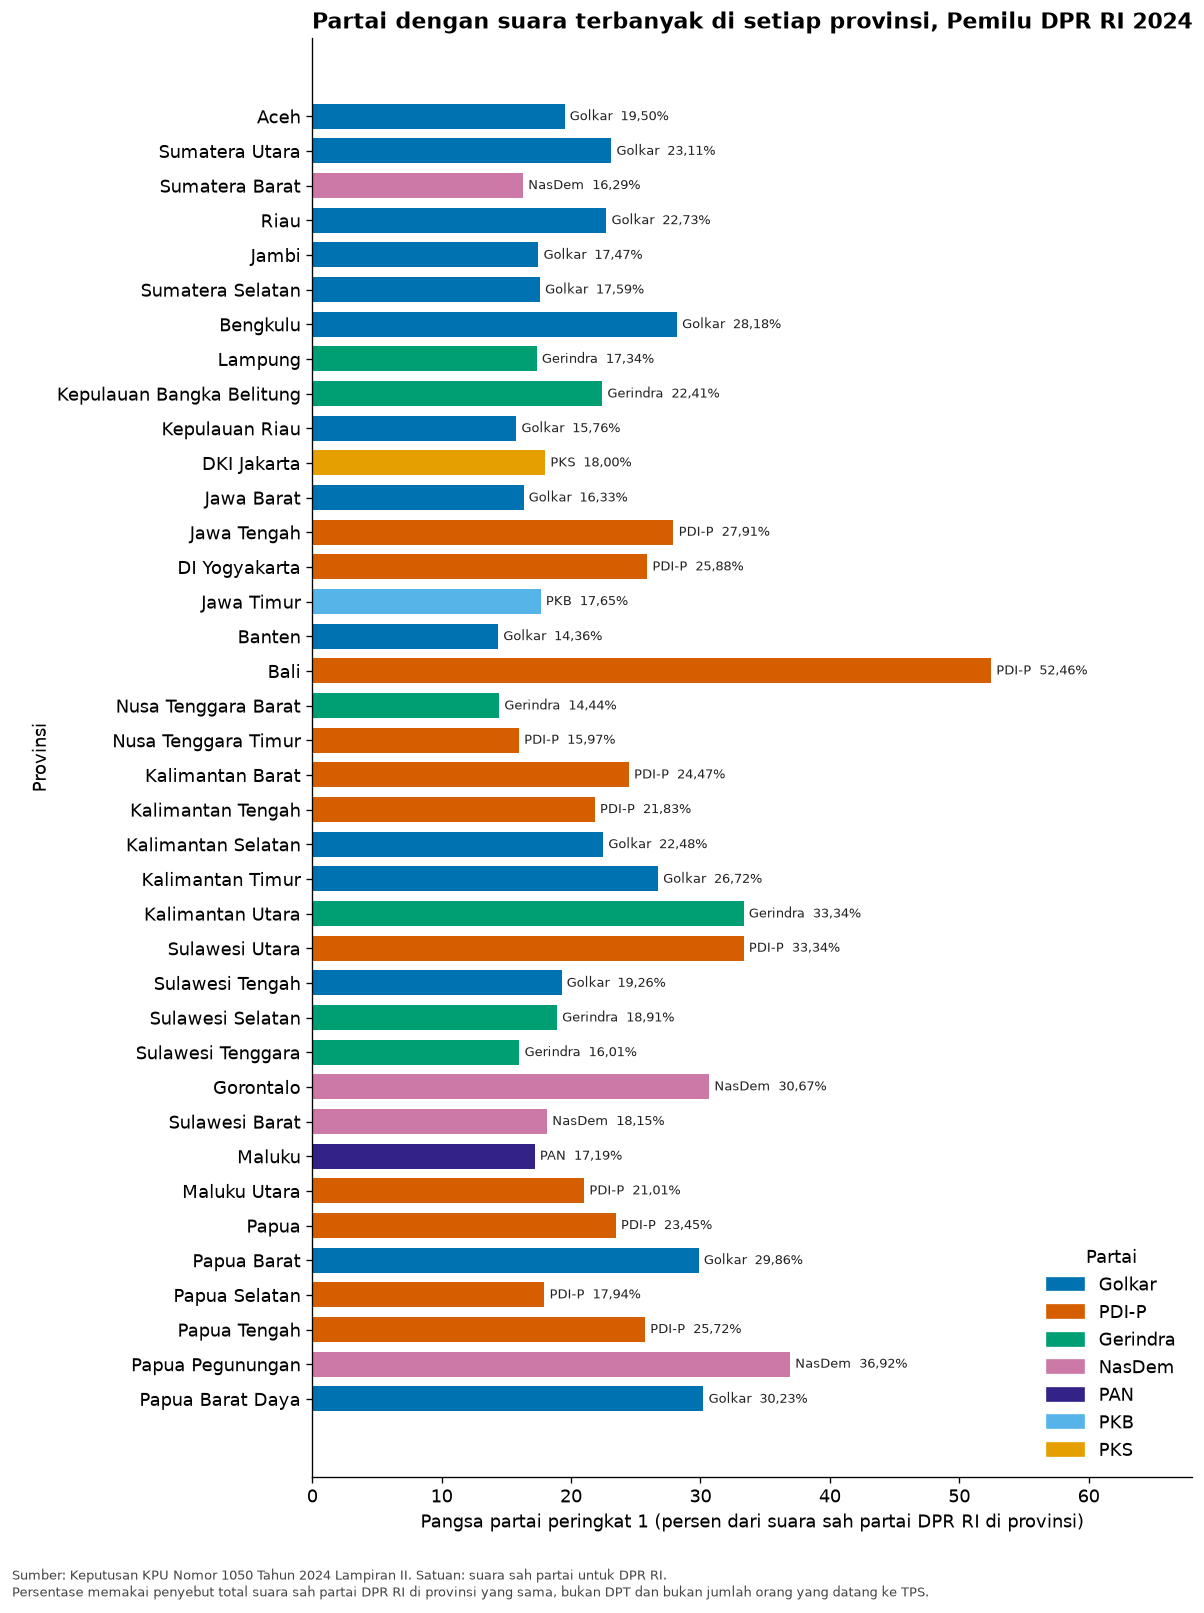

In [4]:
pemenang = (
    detail.loc[detail["peringkat_suara_di_provinsi"] == 1, [
        "provinsi", "nama_partai", "suara_sah_partai_dpr_ri", "persentase_dari_suara_sah_provinsi",
        "total_suara_sah_partai_dpr_ri_provinsi",
    ]]
    .rename(columns={
        "nama_partai": "partai_peringkat_1",
        "suara_sah_partai_dpr_ri": "suara_peringkat_1",
        "persentase_dari_suara_sah_provinsi": "persentase_peringkat_1",
    })
    .set_index("provinsi")
    .loc[urutan_provinsi]
    .reset_index()
)
pemenang["singkatan"] = pemenang["partai_peringkat_1"].map(SINGKATAN)

tabel_pemenang = pemenang.copy()
tabel_pemenang["suara_peringkat_1"] = tabel_pemenang["suara_peringkat_1"].map(fmt_suara)
tabel_pemenang["total_suara_sah_partai_dpr_ri_provinsi"] = tabel_pemenang["total_suara_sah_partai_dpr_ri_provinsi"].map(fmt_suara)
tabel_pemenang["persentase_peringkat_1"] = tabel_pemenang["persentase_peringkat_1"].map(fmt_persen_sumber)
tabel_pemenang = tabel_pemenang.rename(columns={
    "provinsi": "Provinsi",
    "partai_peringkat_1": "Partai dengan suara terbanyak",
    "singkatan": "Singkatan",
    "suara_peringkat_1": "Suara sah",
    "persentase_peringkat_1": "Persentase dari suara sah partai di provinsi",
    "total_suara_sah_partai_dpr_ri_provinsi": "Total suara sah partai DPR RI di provinsi",
})
display(tabel_pemenang.drop(columns=[]))

jumlah_provinsi_pemenang = (
    pemenang.groupby(["partai_peringkat_1", "singkatan"], as_index=False)
    .size()
    .rename(columns={"size": "jumlah_provinsi"})
    .sort_values(["jumlah_provinsi", "singkatan"], ascending=[False, True])
)
display(Markdown(
    "**Fakta.** Tujuh partai menjadi peringkat pertama di sedikitnya satu provinsi. "
    "Hitungan ini menghitung provinsi, bukan menjumlahkan suara."
))
display(jumlah_provinsi_pemenang.rename(columns={
    "partai_peringkat_1": "Partai",
    "singkatan": "Singkatan",
    "jumlah_provinsi": "Jumlah provinsi sebagai peringkat 1",
}))

gambar = pemenang.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 13))
warna = gambar["partai_peringkat_1"].map(WARNA_PARTAI)
ax.barh(gambar["provinsi"], gambar["persentase_peringkat_1"], color=warna, height=0.72)
for urut, baris in enumerate(gambar.itertuples(index=False)):
    ax.text(
        baris.persentase_peringkat_1 + 0.4,
        urut,
        f"{baris.singkatan}  {fmt_persen(baris.persentase_peringkat_1)}",
        va="center",
        ha="left",
        fontsize=8,
        color="#222222",
    )
ax.set_xlabel("Pangsa partai peringkat 1 (persen dari suara sah partai DPR RI di provinsi)")
ax.set_ylabel("Provinsi")
ax.set_xlim(0, 68)
ax.set_title("Partai dengan suara terbanyak di setiap provinsi, Pemilu DPR RI 2024")
pegangan = [
    plt.Rectangle((0, 0), 1, 1, color=WARNA_PARTAI[nama])
    for nama in jumlah_provinsi_pemenang["partai_peringkat_1"]
]
ax.legend(
    pegangan,
    jumlah_provinsi_pemenang["singkatan"].tolist(),
    title="Partai",
    loc="lower right",
    frameon=False,
)
fig.text(0.0, -0.01, CATATAN_GAMBAR, ha="left", va="top", fontsize=8, color="#444444")
fig.tight_layout()
simpan_gambar(fig, "01_partai_suara_terbanyak_per_provinsi.png")
plt.show()

## 7. Posisi Partai Golkar

Bagian ini menjawab empat hal: berapa suara Golkar secara nasional, di berapa provinsi Golkar peringkat pertama, bagaimana peringkat dan persentasenya di setiap provinsi, serta selisihnya terhadap partai pembanding.

Provinsi dengan jumlah suara Golkar tertinggi tidak otomatis sama dengan provinsi dengan persentase tertinggi. Keduanya ditampilkan terpisah di bagian 9.

In [5]:
golkar = (
    detail.loc[detail["nama_partai"] == NAMA_GOLKAR]
    .set_index("provinsi")
    .loc[urutan_provinsi]
    .reset_index()
    .copy()
)

baris_selisih = []
for provinsi, bagian in detail.groupby("provinsi", sort=False):
    baris_golkar = bagian.loc[bagian["nama_partai"] == NAMA_GOLKAR].iloc[0]
    peringkat_1 = bagian.loc[bagian["peringkat_suara_di_provinsi"] == 1].iloc[0]
    peringkat_2 = bagian.loc[bagian["peringkat_suara_di_provinsi"] == 2].iloc[0]
    if int(baris_golkar["peringkat_suara_di_provinsi"]) == 1:
        pembanding = peringkat_2
        makna = "memimpin partai peringkat 2"
    else:
        pembanding = peringkat_1
        makna = "tertinggal dari partai peringkat 1"
    selisih = int(baris_golkar["suara_sah_partai_dpr_ri"] - pembanding["suara_sah_partai_dpr_ri"])
    baris_selisih.append({
        "provinsi": provinsi,
        "partai_pembanding": pembanding["nama_partai"],
        "peringkat_partai_pembanding": int(pembanding["peringkat_suara_di_provinsi"]),
        "suara_partai_pembanding": int(pembanding["suara_sah_partai_dpr_ri"]),
        "persentase_partai_pembanding": float(pembanding["persentase_dari_suara_sah_provinsi"]),
        "selisih_suara_golkar_dikurangi_pembanding": selisih,
        "makna_selisih": makna,
    })

selisih_golkar = pd.DataFrame(baris_selisih)
golkar = golkar.merge(selisih_golkar, on="provinsi", how="left", validate="one_to_one")

total_suara_golkar = int(golkar["suara_sah_partai_dpr_ri"].sum())
pangsa_nasional_golkar = total_suara_golkar / total_suara_nasional * 100
jumlah_peringkat_1 = int((golkar["peringkat_suara_di_provinsi"] == 1).sum())
status_ambang = nasional.loc[nasional["nama_partai"] == NAMA_GOLKAR, "status_ambang_batas_4_persen"].iloc[0]

peringkat_nasional = nasional.sort_values("suara_sah_nasional", ascending=False).reset_index(drop=True)
peringkat_nasional_golkar = int(peringkat_nasional.index[peringkat_nasional["nama_partai"] == NAMA_GOLKAR][0]) + 1

provinsi_peringkat_1 = golkar.loc[golkar["peringkat_suara_di_provinsi"] == 1, "provinsi"].tolist()
tiga_suara_tertinggi = golkar.nlargest(3, "suara_sah_partai_dpr_ri")
tiga_persen_tertinggi = golkar.nlargest(3, "persentase_dari_suara_sah_provinsi")
tiga_suara_terendah = golkar.nsmallest(3, "suara_sah_partai_dpr_ri")
tiga_persen_terendah = golkar.nsmallest(3, "persentase_dari_suara_sah_provinsi")

suara_tiga_terbesar = int(tiga_suara_tertinggi["suara_sah_partai_dpr_ri"].sum())
bagian_tiga_terbesar = suara_tiga_terbesar / total_suara_golkar * 100

unggulan_terkecil = golkar.loc[golkar["peringkat_suara_di_provinsi"] == 1].nsmallest(
    1, "selisih_suara_golkar_dikurangi_pembanding"
).iloc[0]
ketertinggalan_terbesar = golkar.loc[golkar["peringkat_suara_di_provinsi"] != 1].nsmallest(
    1, "selisih_suara_golkar_dikurangi_pembanding"
).iloc[0]

menang_di_bawah_20 = int(
    ((golkar["peringkat_suara_di_provinsi"] == 1) & (golkar["persentase_dari_suara_sah_provinsi"] < 20)).sum()
)

enam_provinsi_jawa = [
    "DKI Jakarta", "Jawa Barat", "Jawa Tengah", "DI Yogyakarta", "Jawa Timur", "Banten",
]
suara_golkar_jawa = int(golkar.loc[golkar["provinsi"].isin(enam_provinsi_jawa), "suara_sah_partai_dpr_ri"].sum())
total_suara_jawa = int(
    detail.loc[detail["provinsi"].isin(enam_provinsi_jawa)]
    .groupby("provinsi")["total_suara_sah_partai_dpr_ri_provinsi"].first().sum()
)

sebaran_peringkat = golkar["peringkat_suara_di_provinsi"].value_counts().sort_index()

display(Markdown(f"""
**Fakta nasional.** Jumlah suara sah Golkar di 38 provinsi adalah **{fmt_suara(total_suara_golkar)}**. Dibagi total suara sah partai DPR RI sebesar {fmt_suara(total_suara_nasional)}, pangsa nasionalnya **{fmt_persen(pangsa_nasional_golkar, 2)}** (nilai hitungan sebelum dibulatkan ke dua desimal: {fmt_persen(pangsa_nasional_golkar, 4)}). Golkar berada di peringkat **{peringkat_nasional_golkar}** nasional menurut jumlah suara. Berkas yang merujuk {SUMBER_NASIONAL} mencatat status ambang batas 4 persen Golkar: **{status_ambang}**.

**Fakta provinsi.** Golkar berada di peringkat pertama di **{jumlah_peringkat_1} dari {n_provinsi} provinsi**: {", ".join(provinsi_peringkat_1)}.

Sebaran peringkat Golkar: {", ".join(f"peringkat {int(k)} di {int(v)} provinsi" for k, v in sebaran_peringkat.items())}. Golkar berada di peringkat 1, 2, atau 3 di {int(sebaran_peringkat.loc[sebaran_peringkat.index <= 3].sum())} provinsi. Peringkat paling rendah adalah {int(golkar["peringkat_suara_di_provinsi"].max())}, di {golkar.loc[golkar["peringkat_suara_di_provinsi"].idxmax(), "provinsi"]}.
"""))

def tabel_cuplikan(bagian, judul):
    tampilan = bagian[[
        "provinsi", "suara_sah_partai_dpr_ri", "persentase_dari_suara_sah_provinsi", "peringkat_suara_di_provinsi",
    ]].copy()
    tampilan["suara_sah_partai_dpr_ri"] = tampilan["suara_sah_partai_dpr_ri"].map(fmt_suara)
    tampilan["persentase_dari_suara_sah_provinsi"] = tampilan["persentase_dari_suara_sah_provinsi"].map(fmt_persen_sumber)
    tampilan = tampilan.rename(columns={
        "provinsi": "Provinsi",
        "suara_sah_partai_dpr_ri": "Suara sah Golkar",
        "persentase_dari_suara_sah_provinsi": "Persentase dari suara sah partai di provinsi",
        "peringkat_suara_di_provinsi": "Peringkat Golkar",
    })
    display(Markdown(f"**{judul}**"))
    display(tampilan)


tabel_cuplikan(tiga_suara_tertinggi, "Tiga provinsi dengan jumlah suara Golkar tertinggi")
tabel_cuplikan(tiga_persen_tertinggi, "Tiga provinsi dengan persentase suara Golkar tertinggi")
tabel_cuplikan(tiga_suara_terendah, "Tiga provinsi dengan jumlah suara Golkar terendah")
tabel_cuplikan(tiga_persen_terendah, "Tiga provinsi dengan persentase suara Golkar terendah")

display(Markdown(f"""
Tiga provinsi dengan suara Golkar terbanyak berjumlah {fmt_suara(suara_tiga_terbesar)} suara, atau {fmt_persen(bagian_tiga_terbesar, 2)} dari seluruh suara Golkar. Jawa Barat, Jawa Timur, dan Jawa Tengah tidak semuanya menempatkan Golkar di peringkat pertama: Jawa Timur peringkat 4 dan Jawa Tengah peringkat 3.

Di antara provinsi tempat Golkar peringkat pertama, selisih terkecil terhadap peringkat kedua ada di **{unggulan_terkecil.provinsi}**: Golkar {fmt_suara(unggulan_terkecil.suara_sah_partai_dpr_ri)} suara, {SINGKATAN[unggulan_terkecil.partai_pembanding]} {fmt_suara(unggulan_terkecil.suara_partai_pembanding)} suara, selisih **{fmt_suara(unggulan_terkecil.selisih_suara_golkar_dikurangi_pembanding)}** suara.

Di antara provinsi tempat Golkar bukan peringkat pertama, ketertinggalan suara terbesar ada di **{ketertinggalan_terbesar.provinsi}**: Golkar tertinggal **{fmt_suara(abs(ketertinggalan_terbesar.selisih_suara_golkar_dikurangi_pembanding))}** suara dari {SINGKATAN[ketertinggalan_terbesar.partai_pembanding]}.

Di {menang_di_bawah_20} dari {jumlah_peringkat_1} provinsi yang menempatkan Golkar di peringkat pertama, persentase Golkar masih di bawah 20. Peringkat pertama di sini berarti suara terbanyak di antara 18 partai, bukan mayoritas dari seluruh suara sah.
"""))


**Fakta nasional.** Jumlah suara sah Golkar di 38 provinsi adalah **23.208.488**. Dibagi total suara sah partai DPR RI sebesar 151.793.293, pangsa nasionalnya **15,29%** (nilai hitungan sebelum dibulatkan ke dua desimal: 15,2895%). Golkar berada di peringkat **2** nasional menurut jumlah suara. Berkas yang merujuk Keputusan KPU Nomor 1204 Tahun 2024 mencatat status ambang batas 4 persen Golkar: **MEMENUHI**.

**Fakta provinsi.** Golkar berada di peringkat pertama di **14 dari 38 provinsi**: Aceh, Sumatera Utara, Riau, Jambi, Sumatera Selatan, Bengkulu, Kepulauan Riau, Jawa Barat, Banten, Kalimantan Selatan, Kalimantan Timur, Sulawesi Tengah, Papua Barat, Papua Barat Daya.

Sebaran peringkat Golkar: peringkat 1 di 14 provinsi, peringkat 2 di 7 provinsi, peringkat 3 di 6 provinsi, peringkat 4 di 4 provinsi, peringkat 5 di 5 provinsi, peringkat 6 di 1 provinsi, peringkat 9 di 1 provinsi. Golkar berada di peringkat 1, 2, atau 3 di 27 provinsi. Peringkat paling rendah adalah 9, di Papua Pegunungan.


**Tiga provinsi dengan jumlah suara Golkar tertinggi**

,Provinsi,Suara sah Golkar,Persentase dari suara sah partai di provinsi,Peringkat Golkar
11,Jawa Barat,4.292.082,"16,3250%",1
14,Jawa Timur,3.232.091,"13,7280%",4
12,Jawa Tengah,2.648.583,"12,6454%",3


**Tiga provinsi dengan persentase suara Golkar tertinggi**

,Provinsi,Suara sah Golkar,Persentase dari suara sah partai di provinsi,Peringkat Golkar
37,Papua Barat Daya,102.786,"30,2287%",1
33,Papua Barat,95.883,"29,8640%",1
6,Bengkulu,324.563,"28,1832%",1


**Tiga provinsi dengan jumlah suara Golkar terendah**

,Provinsi,Suara sah Golkar,Persentase dari suara sah partai di provinsi,Peringkat Golkar
36,Papua Pegunungan,9.866,"0,7552%",9
23,Kalimantan Utara,24.992,"6,5862%",5
34,Papua Selatan,30.449,"10,0364%",5


**Tiga provinsi dengan persentase suara Golkar terendah**

,Provinsi,Suara sah Golkar,Persentase dari suara sah partai di provinsi,Peringkat Golkar
36,Papua Pegunungan,9.866,"0,7552%",9
23,Kalimantan Utara,24.992,"6,5862%",5
30,Maluku,87.508,"8,4129%",6



Tiga provinsi dengan suara Golkar terbanyak berjumlah 10.172.756 suara, atau 43,83% dari seluruh suara Golkar. Jawa Barat, Jawa Timur, dan Jawa Tengah tidak semuanya menempatkan Golkar di peringkat pertama: Jawa Timur peringkat 4 dan Jawa Tengah peringkat 3.

Di antara provinsi tempat Golkar peringkat pertama, selisih terkecil terhadap peringkat kedua ada di **Kepulauan Riau**: Golkar 166.147 suara, Gerindra 164.310 suara, selisih **1.837** suara.

Di antara provinsi tempat Golkar bukan peringkat pertama, ketertinggalan suara terbesar ada di **Jawa Tengah**: Golkar tertinggal **3.197.910** suara dari PDI-P.

Di 7 dari 14 provinsi yang menempatkan Golkar di peringkat pertama, persentase Golkar masih di bawah 20. Peringkat pertama di sini berarti suara terbanyak di antara 18 partai, bukan mayoritas dari seluruh suara sah.


In [6]:
tabel_golkar = golkar[[
    "provinsi",
    "peringkat_suara_di_provinsi",
    "suara_sah_partai_dpr_ri",
    "persentase_dari_suara_sah_provinsi",
    "total_suara_sah_partai_dpr_ri_provinsi",
    "partai_pembanding",
    "peringkat_partai_pembanding",
    "suara_partai_pembanding",
    "selisih_suara_golkar_dikurangi_pembanding",
    "makna_selisih",
    "sumber_keputusan",
    "url_sumber",
]].copy()
tabel_golkar.insert(0, "nomor_urut_pada_berkas_sumber", range(1, len(tabel_golkar) + 1))
tabel_golkar["penyebut_persentase"] = (
    "total suara sah partai DPR RI di provinsi yang sama"
)
tabel_golkar["aturan_tanda_selisih"] = (
    "Positif bila Golkar peringkat 1 dan selisih dihitung terhadap peringkat 2. "
    "Negatif bila Golkar bukan peringkat 1 dan selisih dihitung terhadap peringkat 1."
)

jalur_csv = OUT / "ringkasan_golkar_per_provinsi_2024.csv"
tabel_golkar.to_csv(jalur_csv, index=False)
print(f"CSV disimpan: {jalur_csv.relative_to(ROOT)} ({len(tabel_golkar)} baris)")

tampilan_penuh = tabel_golkar[[
    "provinsi",
    "peringkat_suara_di_provinsi",
    "suara_sah_partai_dpr_ri",
    "persentase_dari_suara_sah_provinsi",
    "partai_pembanding",
    "selisih_suara_golkar_dikurangi_pembanding",
    "makna_selisih",
]].copy()
tampilan_penuh["suara_sah_partai_dpr_ri"] = tampilan_penuh["suara_sah_partai_dpr_ri"].map(fmt_suara)
tampilan_penuh["persentase_dari_suara_sah_provinsi"] = tampilan_penuh["persentase_dari_suara_sah_provinsi"].map(fmt_persen_sumber)
tampilan_penuh["selisih_suara_golkar_dikurangi_pembanding"] = tampilan_penuh["selisih_suara_golkar_dikurangi_pembanding"].map(
    lambda nilai: f"{fmt_suara(abs(nilai))}" if nilai < 0 else fmt_suara(nilai)
)
# Tanda minus dipertahankan pada kolom makna; kolom angka di tabel baca memakai tanda eksplisit.
tampilan_penuh["selisih_dengan_tanda"] = tabel_golkar["selisih_suara_golkar_dikurangi_pembanding"].map(
    lambda nilai: ("+" if nilai > 0 else "−") + fmt_suara(abs(nilai))
)
tampilan_penuh = tampilan_penuh.drop(columns=["selisih_suara_golkar_dikurangi_pembanding"])
tampilan_penuh = tampilan_penuh.rename(columns={
    "provinsi": "Provinsi",
    "peringkat_suara_di_provinsi": "Peringkat",
    "suara_sah_partai_dpr_ri": "Suara Golkar",
    "persentase_dari_suara_sah_provinsi": "Persentase",
    "partai_pembanding": "Partai pembanding",
    "makna_selisih": "Posisi selisih",
    "selisih_dengan_tanda": "Selisih suara",
})
display(Markdown(
    "Tabel lengkap Golkar di 38 provinsi. Tanda plus pada selisih berarti Golkar memimpin partai peringkat 2. "
    "Tanda minus berarti Golkar tertinggal dari partai peringkat 1. Persentase memakai penyebut total suara sah partai DPR RI di provinsi itu."
))
display(tampilan_penuh[[
    "Provinsi", "Peringkat", "Suara Golkar", "Persentase", "Partai pembanding", "Selisih suara", "Posisi selisih",
]])

CSV disimpan: outputs\ringkasan_golkar_per_provinsi_2024.csv (38 baris)


Tabel lengkap Golkar di 38 provinsi. Tanda plus pada selisih berarti Golkar memimpin partai peringkat 2. Tanda minus berarti Golkar tertinggal dari partai peringkat 1. Persentase memakai penyebut total suara sah partai DPR RI di provinsi itu.

,Provinsi,Peringkat,Suara Golkar,Persentase,Partai pembanding,Selisih suara,Posisi selisih
0,Aceh,1,594.213,"19,4969%",Partai Kebangkitan Bangsa,+6.430,memimpin partai peringkat 2
1,Sumatera Utara,1,1.712.074,"23,1093%",Partai Demokrasi Indonesia Perjuangan,+329.025,memimpin partai peringkat 2
2,Sumatera Barat,5,354.500,"12,1394%",Partai NasDem,−121.086,tertinggal dari partai peringkat 1
3,Riau,1,770.977,"22,7275%",Partai Demokrasi Indonesia Perjuangan,+339.800,memimpin partai peringkat 2
4,Jambi,1,341.039,"17,4737%",Partai Demokrasi Indonesia Perjuangan,+22.915,memimpin partai peringkat 2
5,Sumatera Selatan,1,857.642,"17,5934%",Partai NasDem,+22.962,memimpin partai peringkat 2
6,Bengkulu,1,324.563,"28,1832%",Partai Amanat Nasional,+136.217,memimpin partai peringkat 2
7,Lampung,3,670.414,"14,4118%",Partai Gerakan Indonesia Raya,−136.422,tertinggal dari partai peringkat 1
8,Kepulauan Bangka Belitung,3,115.549,"14,9711%",Partai Gerakan Indonesia Raya,−57.400,tertinggal dari partai peringkat 1
9,Kepulauan Riau,1,166.147,"15,7635%",Partai Gerakan Indonesia Raya,+1.837,memimpin partai peringkat 2


## 8. Grafik Golkar

Tiga grafik berikut saling melengkapi.

- Grafik pertama mengurutkan provinsi menurut **jumlah suara**. Provinsi besar cenderung muncul di sini.
- Grafik kedua mengurutkan menurut **pangsa**. Provinsi dengan pemilih lebih sedikit bisa muncul di sini bila porsi Golkar di provinsi itu tinggi.
- Grafik ketiga menunjukkan **peringkat** Golkar di seluruh provinsi. Panjang batang tetap pangsa, supaya peringkat tidak terlihat “besar” hanya karena angkanya 9. Peringkat ditulis di depan nama provinsi. Urutan dari peringkat 1 di atas menuju peringkat yang lebih rendah di bawah.

Gambar disimpan: outputs\gambar\02_golkar_10_provinsi_suara_terbanyak.png


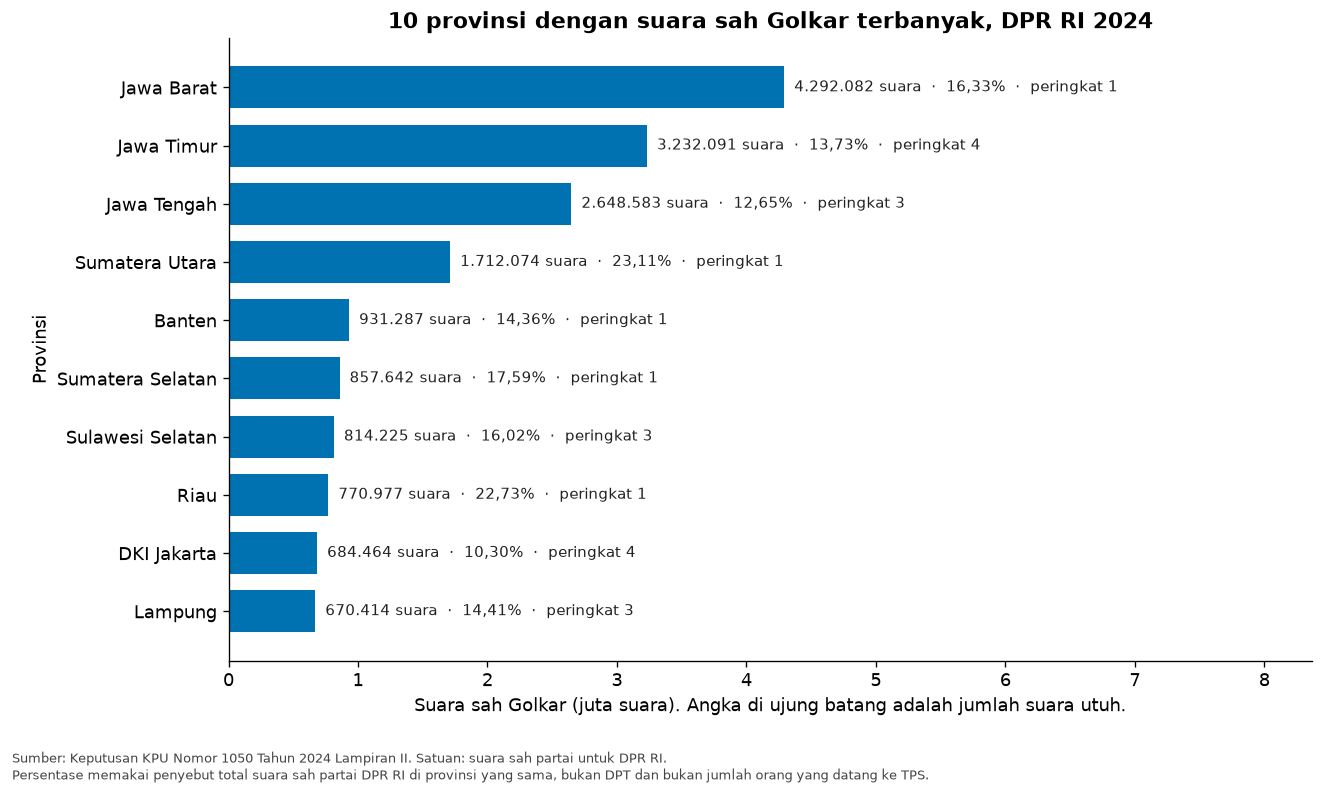

Gambar disimpan: outputs\gambar\03_golkar_10_provinsi_pangsa_tertinggi.png


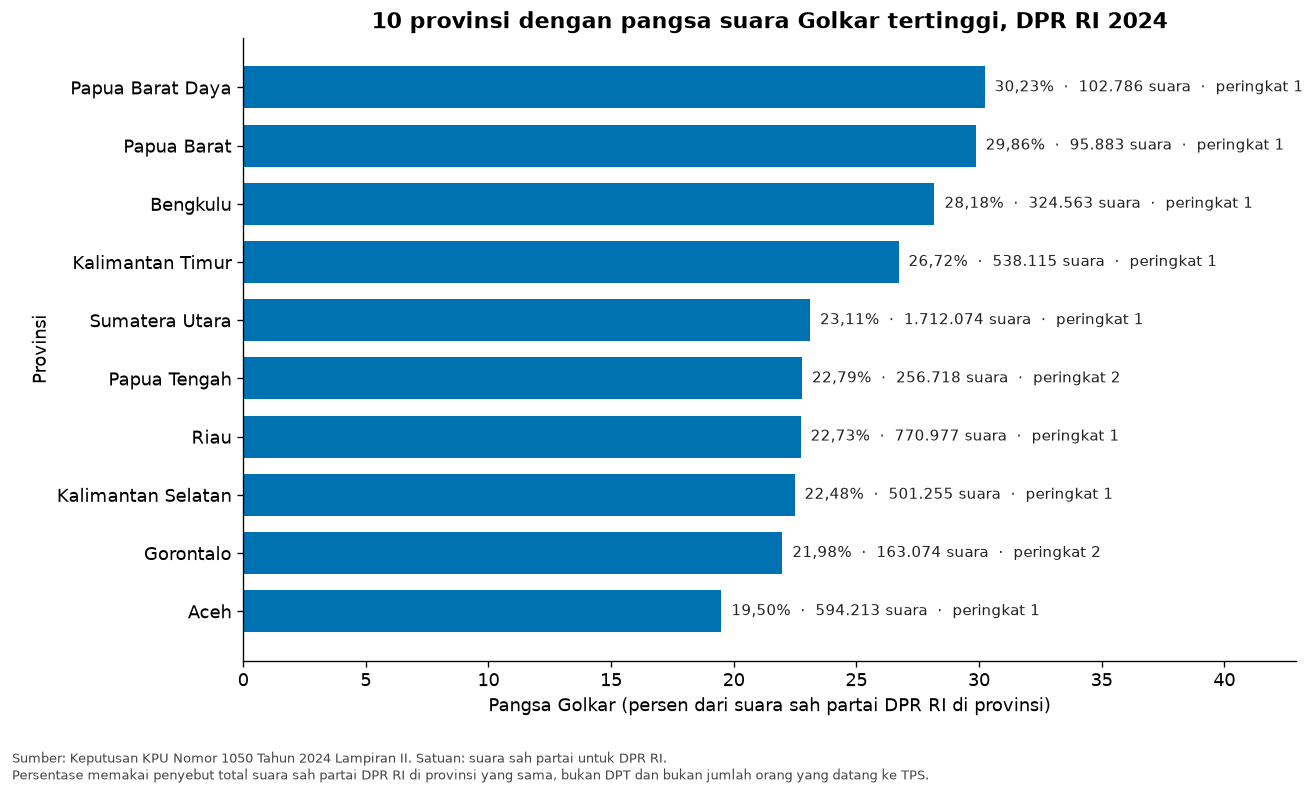

Gambar disimpan: outputs\gambar\04_peringkat_golkar_seluruh_provinsi.png


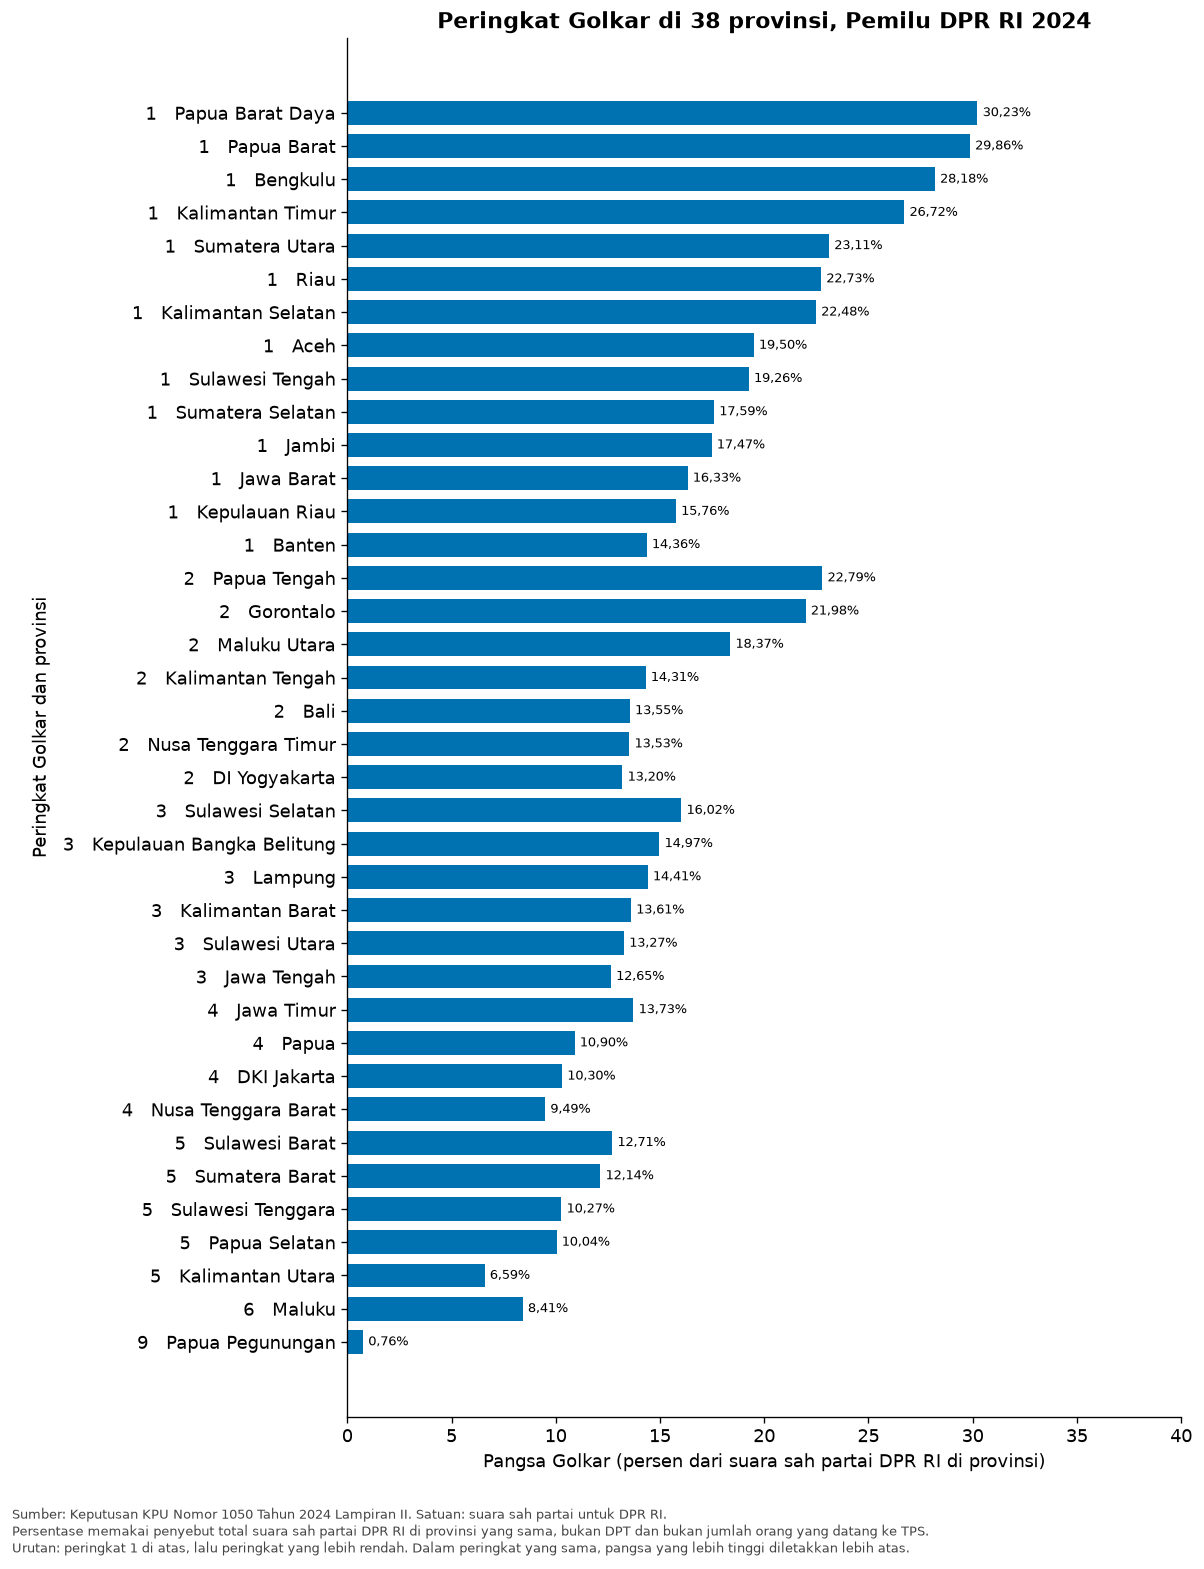

In [7]:
def grafik_batang_golkar(bagian, kolom_nilai, judul, label_sumbu, nama_berkas, pemformat):
    from matplotlib.ticker import MultipleLocator

    gambar = bagian.iloc[::-1]
    skala_juta = kolom_nilai == "suara_sah_partai_dpr_ri"
    fig, ax = plt.subplots(figsize=(11, 6.2))
    nilai_plot = gambar[kolom_nilai] / 1_000_000 if skala_juta else gambar[kolom_nilai]
    if skala_juta:
        label_sumbu = (
            "Suara sah Golkar (juta suara). Angka di ujung batang adalah jumlah suara utuh."
        )
    ax.barh(gambar["provinsi"], nilai_plot, color="#0072B2", height=0.72)
    for urut, baris in enumerate(gambar.itertuples(index=False)):
        x = getattr(baris, kolom_nilai) / (1_000_000 if skala_juta else 1)
        ax.text(
            x,
            urut,
            "  " + pemformat(baris),
            va="center",
            ha="left",
            fontsize=9,
            color="#222222",
        )
    batas = float(nilai_plot.max())
    ax.set_xlim(0, batas * (1.95 if skala_juta else 1.42))
    if skala_juta:
        ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.set_xlabel(label_sumbu)
    ax.set_ylabel("Provinsi")
    ax.set_title(judul)
    fig.text(0.0, -0.02, CATATAN_GAMBAR, ha="left", va="top", fontsize=8, color="#444444")
    fig.tight_layout()
    simpan_gambar(fig, nama_berkas)
    plt.show()


sepuluh_suara = golkar.nlargest(10, "suara_sah_partai_dpr_ri")
grafik_batang_golkar(
    sepuluh_suara,
    "suara_sah_partai_dpr_ri",
    "10 provinsi dengan suara sah Golkar terbanyak, DPR RI 2024",
    "Suara sah Golkar (suara)",
    "02_golkar_10_provinsi_suara_terbanyak.png",
    lambda baris: (
        f"{fmt_suara(baris.suara_sah_partai_dpr_ri)} suara"
        f"  ·  {fmt_persen(baris.persentase_dari_suara_sah_provinsi)}"
        f"  ·  peringkat {int(baris.peringkat_suara_di_provinsi)}"
    ),
)

sepuluh_persen = golkar.nlargest(10, "persentase_dari_suara_sah_provinsi")
grafik_batang_golkar(
    sepuluh_persen,
    "persentase_dari_suara_sah_provinsi",
    "10 provinsi dengan pangsa suara Golkar tertinggi, DPR RI 2024",
    "Pangsa Golkar (persen dari suara sah partai DPR RI di provinsi)",
    "03_golkar_10_provinsi_pangsa_tertinggi.png",
    lambda baris: (
        f"{fmt_persen(baris.persentase_dari_suara_sah_provinsi)}"
        f"  ·  {fmt_suara(baris.suara_sah_partai_dpr_ri)} suara"
        f"  ·  peringkat {int(baris.peringkat_suara_di_provinsi)}"
    ),
)

urut_peringkat = golkar.sort_values(
    ["peringkat_suara_di_provinsi", "persentase_dari_suara_sah_provinsi", "provinsi"],
    ascending=[True, False, True],
).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 12.5))
ax.barh(
    [f"{int(p):>2}   {n}" for p, n in zip(urut_peringkat["peringkat_suara_di_provinsi"], urut_peringkat["provinsi"])],
    urut_peringkat["persentase_dari_suara_sah_provinsi"],
    color="#0072B2",
    height=0.72,
)
for urut, baris in enumerate(urut_peringkat.itertuples(index=False)):
    ax.text(
        baris.persentase_dari_suara_sah_provinsi + 0.25,
        urut,
        fmt_persen(baris.persentase_dari_suara_sah_provinsi),
        va="center",
        ha="left",
        fontsize=8,
    )
ax.set_xlim(0, 40)
ax.set_xlabel("Pangsa Golkar (persen dari suara sah partai DPR RI di provinsi)")
ax.set_ylabel("Peringkat Golkar dan provinsi")
ax.set_title("Peringkat Golkar di 38 provinsi, Pemilu DPR RI 2024")
fig.text(0.0, -0.01, CATATAN_GAMBAR + "\nUrutan: peringkat 1 di atas, lalu peringkat yang lebih rendah. Dalam peringkat yang sama, pangsa yang lebih tinggi diletakkan lebih atas.", ha="left", va="top", fontsize=8, color="#444444")
fig.tight_layout()
simpan_gambar(fig, "04_peringkat_golkar_seluruh_provinsi.png")
plt.show()

## 9. Jumlah suara dan pangsa suara

Dua ukuran ini menjawab pertanyaan yang berbeda.

- **Jumlah suara** menghitung berapa suara sah yang tercatat untuk Golkar. Provinsi dengan lebih banyak suara sah secara keseluruhan berpeluang menyumbang jumlah yang besar, walaupun porsi Golkar di sana sedang.
- **Pangsa suara** menghitung porsi Golkar di antara suara sah partai DPR RI di provinsi itu. Penyebutnya berubah dari provinsi ke provinsi. Pangsa 30 persen di provinsi kecil bisa berarti jauh lebih sedikit suara daripada pangsa 16 persen di provinsi besar.

Karena itu, daftar “suara tertinggi” dan daftar “pangsa tertinggi” tidak harus berisi provinsi yang sama. Ini perbedaan definisi, bukan bukti bahwa pemilih di satu tempat lebih atau kurang mendukung.

In [8]:
jabar = golkar.loc[golkar["provinsi"] == "Jawa Barat"].iloc[0]
papua_barat_daya = golkar.loc[golkar["provinsi"] == "Papua Barat Daya"].iloc[0]
rasio_suara = jabar["suara_sah_partai_dpr_ri"] / papua_barat_daya["suara_sah_partai_dpr_ri"]

display(Markdown(f"""
**Contoh dari data ini.** Jawa Barat mencatat {fmt_suara(jabar.suara_sah_partai_dpr_ri)} suara Golkar, atau {fmt_persen_sumber(jabar.persentase_dari_suara_sah_provinsi)} dari suara sah partai di provinsi itu. Papua Barat Daya mencatat {fmt_suara(papua_barat_daya.suara_sah_partai_dpr_ri)} suara, atau {fmt_persen_sumber(papua_barat_daya.persentase_dari_suara_sah_provinsi)}.

Jumlah suara Golkar di Jawa Barat sekitar **{rasio_suara:.0f} kali** jumlah di Papua Barat Daya. Pangsa di Papua Barat Daya justru lebih tinggi: {fmt_persen_sumber(papua_barat_daya.persentase_dari_suara_sah_provinsi)} dibanding {fmt_persen_sumber(jabar.persentase_dari_suara_sah_provinsi)}. Keduanya menempatkan Golkar di peringkat 1. Peringkat yang sama tidak berarti jumlah suara yang sama.

Tiga pangsa tertinggi (Papua Barat Daya, Papua Barat, dan Bengkulu) semuanya di bawah 330 ribu suara Golkar. Tiga jumlah tertinggi (Jawa Barat, Jawa Timur, dan Jawa Tengah) semuanya di atas 2,6 juta suara, dengan pangsa antara {fmt_persen_sumber(tiga_suara_tertinggi["persentase_dari_suara_sah_provinsi"].min())} dan {fmt_persen_sumber(tiga_suara_tertinggi["persentase_dari_suara_sah_provinsi"].max())}.
"""))

display(Markdown(f"""
**Sebaran jumlah, sebagai deskripsi.** Enam provinsi di Pulau Jawa yang ada dalam data — DKI Jakarta, Jawa Barat, Jawa Tengah, DI Yogyakarta, Jawa Timur, dan Banten — memuat {fmt_suara(suara_golkar_jawa)} suara Golkar. Itu {fmt_persen(suara_golkar_jawa / total_suara_golkar * 100, 2)} dari seluruh suara Golkar. Enam provinsi yang sama memuat {fmt_suara(total_suara_jawa)} suara sah partai, atau {fmt_persen(total_suara_jawa / total_suara_nasional * 100, 2)} dari total nasional.

Pengelompokan ini dipilih di notebook karena nama provinsi itu berada di Pulau Jawa. Berkas sumber tidak punya kolom pulau. Angka di atas tidak menjelaskan penyebab sebaran.
"""))


**Contoh dari data ini.** Jawa Barat mencatat 4.292.082 suara Golkar, atau 16,3250% dari suara sah partai di provinsi itu. Papua Barat Daya mencatat 102.786 suara, atau 30,2287%.

Jumlah suara Golkar di Jawa Barat sekitar **42 kali** jumlah di Papua Barat Daya. Pangsa di Papua Barat Daya justru lebih tinggi: 30,2287% dibanding 16,3250%. Keduanya menempatkan Golkar di peringkat 1. Peringkat yang sama tidak berarti jumlah suara yang sama.

Tiga pangsa tertinggi (Papua Barat Daya, Papua Barat, dan Bengkulu) semuanya di bawah 330 ribu suara Golkar. Tiga jumlah tertinggi (Jawa Barat, Jawa Timur, dan Jawa Tengah) semuanya di atas 2,6 juta suara, dengan pangsa antara 12,6454% dan 16,3250%.



**Sebaran jumlah, sebagai deskripsi.** Enam provinsi di Pulau Jawa yang ada dalam data — DKI Jakarta, Jawa Barat, Jawa Tengah, DI Yogyakarta, Jawa Timur, dan Banten — memuat 12.091.352 suara Golkar. Itu 52,10% dari seluruh suara Golkar. Enam provinsi yang sama memuat 86.201.849 suara sah partai, atau 56,79% dari total nasional.

Pengelompokan ini dipilih di notebook karena nama provinsi itu berada di Pulau Jawa. Berkas sumber tidak punya kolom pulau. Angka di atas tidak menjelaskan penyebab sebaran.


## 10. Perbandingan singkat dengan partai lain

Perbandingan di bawah memakai dua ukuran yang sengaja tidak dicampur.

- Urutan nasional memakai **jumlah suara** di 38 provinsi.
- Sebaran peringkat pertama memakai **jumlah provinsi**, tanpa menjumlahkan suara provinsi kecil dan besar menjadi satu.

Golkar bisa memimpin di lebih banyak provinsi daripada partai yang suara nasionalnya lebih besar. Itu bukan pertentangan. Dua kolom itu memang tidak mengukur hal yang sama.

In [9]:
nasional_urut = nasional.sort_values("suara_sah_nasional", ascending=False).reset_index(drop=True).copy()
nasional_urut["peringkat_nasional"] = nasional_urut.index + 1
nasional_urut["pangsa_nasional_persen"] = nasional_urut["suara_sah_nasional"] / total_suara_nasional * 100
nasional_urut["singkatan"] = nasional_urut["nama_partai"].map(SINGKATAN)

tampilan_nasional = pd.DataFrame({
    "Peringkat": nasional_urut["peringkat_nasional"],
    "Partai": nasional_urut["nama_partai"],
    "Suara sah nasional": nasional_urut["suara_sah_nasional"].map(fmt_suara),
    "Pangsa dari total suara sah partai": nasional_urut["pangsa_nasional_persen"].map(lambda nilai: fmt_persen(nilai, 2)),
    "Ambang batas 4 persen": nasional_urut["status_ambang_batas_4_persen"],
})
display(Markdown(
    f"Total penyebut pangsa nasional adalah {fmt_suara(total_suara_nasional)} suara sah partai DPR RI, "
    f"sesuai berkas {SUMBER_NASIONAL}. Pangsa nasional dihitung di notebook, lalu dibulatkan ke 2 desimal pada tabel ini."
))
display(tampilan_nasional)

gabung_ukuran = jumlah_provinsi_pemenang.merge(
    nasional_urut[["nama_partai", "peringkat_nasional", "suara_sah_nasional", "pangsa_nasional_persen"]],
    left_on="partai_peringkat_1",
    right_on="nama_partai",
    how="left",
).sort_values("peringkat_nasional")

tampilan_ukuran = pd.DataFrame({
    "Partai": gabung_ukuran["singkatan"],
    "Peringkat nasional menurut jumlah suara": gabung_ukuran["peringkat_nasional"],
    "Suara sah nasional": gabung_ukuran["suara_sah_nasional"].map(fmt_suara),
    "Jumlah provinsi sebagai peringkat 1": gabung_ukuran["jumlah_provinsi"],
})
display(Markdown(
    "**Fakta.** Di antara partai yang pernah menjadi peringkat pertama di suatu provinsi, urutan jumlah suara nasional dan urutan jumlah provinsi tidak sama."
))
display(tampilan_ukuran)

di_tiga_besar = (
    detail.loc[detail["peringkat_suara_di_provinsi"] <= 3, "nama_partai"]
    .value_counts()
    .rename_axis("partai")
    .reset_index(name="provinsi_di_peringkat_1_sampai_3")
)
di_tiga_besar["singkatan"] = di_tiga_besar["partai"].map(SINGKATAN)
display(Markdown(
    "Jumlah provinsi tempat suatu partai berada di peringkat 1, 2, atau 3. Satu provinsi dihitung tiga kali, sekali untuk tiap partai pada tiga peringkat teratas. Ini bukan jumlah suara."
))
display(di_tiga_besar[["singkatan", "provinsi_di_peringkat_1_sampai_3"]].rename(columns={
    "singkatan": "Partai",
    "provinsi_di_peringkat_1_sampai_3": "Jumlah provinsi di peringkat 1–3",
}))

pdi = nasional_urut.loc[nasional_urut["nama_partai"] == "Partai Demokrasi Indonesia Perjuangan"].iloc[0]
gerindra = nasional_urut.loc[nasional_urut["nama_partai"] == "Partai Gerakan Indonesia Raya"].iloc[0]
display(Markdown(f"""
Secara nasional, PDI-P berada di peringkat 1 dengan {fmt_suara(pdi.suara_sah_nasional)} suara ({fmt_persen(pdi.pangsa_nasional_persen, 2)}). Golkar peringkat 2 dengan {fmt_suara(total_suara_golkar)} suara ({fmt_persen(pangsa_nasional_golkar, 2)}). Gerindra peringkat 3 dengan {fmt_suara(gerindra.suara_sah_nasional)} suara ({fmt_persen(gerindra.pangsa_nasional_persen, 2)}).

Menurut jumlah provinsi, Golkar peringkat pertama di {jumlah_peringkat_1} provinsi dan PDI-P di {int(jumlah_provinsi_pemenang.loc[jumlah_provinsi_pemenang["singkatan"] == "PDI-P", "jumlah_provinsi"].iloc[0])} provinsi. Golkar dan PDI-P sama-sama muncul di peringkat 1–3 pada {int(di_tiga_besar.loc[di_tiga_besar["singkatan"] == "Golkar", "provinsi_di_peringkat_1_sampai_3"].iloc[0])} provinsi, belum tentu provinsi yang sama.

**Bukan kesimpulan.** Selisih nasional antara PDI-P dan Golkar tidak menjelaskan apa yang terjadi di tiap provinsi. Di sebagian provinsi Golkar memimpin. Di provinsi lain, termasuk Jawa Tengah dan Bali pada tabel Golkar di atas, Golkar berada di belakang dengan selisih suara yang besar. Notebook ini berhenti pada deskripsi itu.
"""))

Total penyebut pangsa nasional adalah 151.793.293 suara sah partai DPR RI, sesuai berkas Keputusan KPU Nomor 1204 Tahun 2024. Pangsa nasional dihitung di notebook, lalu dibulatkan ke 2 desimal pada tabel ini.

,Peringkat,Partai,Suara sah nasional,Pangsa dari total suara sah partai,Ambang batas 4 persen
0,1,Partai Demokrasi Indonesia Perjuangan,25.384.673,"16,72%",MEMENUHI
1,2,Partai Golongan Karya,23.208.488,"15,29%",MEMENUHI
2,3,Partai Gerakan Indonesia Raya,20.071.345,"13,22%",MEMENUHI
3,4,Partai Kebangkitan Bangsa,16.115.358,"10,62%",MEMENUHI
4,5,Partai NasDem,14.660.328,"9,66%",MEMENUHI
5,6,Partai Keadilan Sejahtera,12.781.241,"8,42%",MEMENUHI
6,7,Partai Demokrat,11.283.053,"7,43%",MEMENUHI
7,8,Partai Amanat Nasional,10.984.639,"7,24%",MEMENUHI
8,9,Partai Persatuan Pembangunan,5.878.708,"3,87%",TIDAK MEMENUHI
9,10,Partai Solidaritas Indonesia,4.260.108,"2,81%",TIDAK MEMENUHI


**Fakta.** Di antara partai yang pernah menjadi peringkat pertama di suatu provinsi, urutan jumlah suara nasional dan urutan jumlah provinsi tidak sama.

,Partai,Peringkat nasional menurut jumlah suara,Suara sah nasional,Jumlah provinsi sebagai peringkat 1
1,PDI-P,1,25.384.673,11
0,Golkar,2,23.208.488,14
2,Gerindra,3,20.071.345,6
5,PKB,4,16.115.358,1
3,NasDem,5,14.660.328,4
6,PKS,6,12.781.241,1
4,PAN,8,10.984.639,1


Jumlah provinsi tempat suatu partai berada di peringkat 1, 2, atau 3. Satu provinsi dihitung tiga kali, sekali untuk tiap partai pada tiga peringkat teratas. Ini bukan jumlah suara.

,Partai,Jumlah provinsi di peringkat 1–3
0,Golkar,27
1,PDI-P,27
2,Gerindra,21
3,NasDem,17
4,PKS,6
5,Demokrat,6
6,PKB,5
7,PAN,5



Secara nasional, PDI-P berada di peringkat 1 dengan 25.384.673 suara (16,72%). Golkar peringkat 2 dengan 23.208.488 suara (15,29%). Gerindra peringkat 3 dengan 20.071.345 suara (13,22%).

Menurut jumlah provinsi, Golkar peringkat pertama di 14 provinsi dan PDI-P di 11 provinsi. Golkar dan PDI-P sama-sama muncul di peringkat 1–3 pada 27 provinsi, belum tentu provinsi yang sama.

**Bukan kesimpulan.** Selisih nasional antara PDI-P dan Golkar tidak menjelaskan apa yang terjadi di tiap provinsi. Di sebagian provinsi Golkar memimpin. Di provinsi lain, termasuk Jawa Tengah dan Bali pada tabel Golkar di atas, Golkar berada di belakang dengan selisih suara yang besar. Notebook ini berhenti pada deskripsi itu.


## 11. Fakta dan batas interpretasi

Yang dapat dikatakan dari berkas ini:

- Berapa suara sah yang tercatat untuk tiap partai, di tiap provinsi dan secara nasional.
- Siapa yang suaranya terbanyak di suatu provinsi, dan berapa selisihnya terhadap partai di peringkat berikutnya atau di peringkat pertama.
- Bahwa jumlah suara dan pangsa suara mengurutkan provinsi secara berbeda.

Yang tidak dapat dikatakan:

- Penyebab pola tersebut, termasuk peran tokoh, organisasi, wilayah, atau kampanye. Data ini tidak memuat keterangan itu.
- Sikap atau sentimen publik. Belum ada post yang dianotasi.
- Hubungan antara percakapan di X dan hasil Pemilu.
- Perolehan kursi. Berkas ini berisi suara, bukan alokasi kursi.
- Partisipasi pemilih. DPT dan jumlah orang yang datang ke TPS tidak ada di CSV.

Peringkat pertama juga bukan mayoritas. Di banyak provinsi, partai terdepan memegang kurang dari setengah suara sah. Suara yang tersisa tersebar di partai lain.

## 12. Pertanyaan untuk dataset sentimen, belum dijawab

Pertanyaan di bawah baru bisa diteliti ketika post X sudah terkumpul dan label sentimennya terisi. Data suara **tidak** dipakai untuk menjawabnya. Jawaban juga tidak boleh meminjam urutan provinsi pada notebook ini seolah-olah urutan itu sudah menggambarkan isi percakapan.

1. Setelah anotasi selesai, apakah sebaran sentimen pada post tentang Golkar mengikuti pangsa suara provinsi, mengikuti jumlah suara, atau tidak mengikuti keduanya?
2. Di provinsi dengan selisih suara tipis, seperti Kepulauan Riau pada tabel suara, apakah post yang berhasil dikumpulkan menyebut Golkar dan partai pembanding dengan frekuensi yang sebanding? Itu pertanyaan tentang sampel post, bukan tentang selisih 1.837 suara.
3. Di provinsi dengan pangsa Golkar sangat kecil, seperti Papua Pegunungan pada tabel suara, apakah sedikitnya sebutan nanti mencerminkan percakapan yang memang jarang, atau hanya batas cara data dikumpulkan?
4. Bagaimana post tentang Partai Golkar pada pemilu DPR RI dipisahkan dari post tentang tokoh, pemerintahan daerah, atau isu lain, sebelum sentimen dihitung?
5. Apa arti label positif, negatif, dan netral, siapa yang memberi label, dan berapa post per provinsi yang lolos? Tanpa jumlah itu, perbandingan sentimen antarprovinsi belum bisa dibaca.

Kalimat pembuka setiap pertanyaan boleh menyebut contoh provinsi dari hasil suara sebagai **konteks elektoral**. Isi sentimennya tetap harus diukur dari post, pada tahap terpisah.

Bagian 14 dan seterusnya mulai membaca berkas post yang sudah tersedia. Prediksi model pada post itu tetap tidak menjawab pertanyaan per provinsi di atas. Berkas post tidak memuat kolom provinsi, dan prediksi model bukan label manusia yang sudah diverifikasi.

## 13. Berkas yang dihasilkan notebook ini

Setelah semua sel dijalankan, notebook menulis:

- `outputs/ringkasan_golkar_per_provinsi_2024.csv` — satu baris per provinsi untuk Golkar, termasuk peringkat, persentase, partai pembanding, dan selisih.
- `outputs/gambar/01_partai_suara_terbanyak_per_provinsi.png`
- `outputs/gambar/02_golkar_10_provinsi_suara_terbanyak.png`
- `outputs/gambar/03_golkar_10_provinsi_pangsa_tertinggi.png`
- `outputs/gambar/04_peringkat_golkar_seluruh_provinsi.png`

Ringkasan satu halaman untuk pembaca nonteknis berada di `ringkasan_temuan_nonteknis.md` pada folder proyek. Angka di ringkasan itu diambil dari hasil pemeriksaan dan hitungan di notebook ini.

CSV keluaran adalah tabel analisis, bukan dokumen KPU. Kolom suara, persentase, dan peringkat disalin dari sumber yang sudah diperiksa. Kolom selisih dihitung dengan aturan pada bagian metode.

Berkas sentimen post ditulis di bagian 22. Dataset sumber di folder `datasets/` tidak ditimpa.

## 14. Post X: berkas terpisah dari hasil suara

Bagian ini tidak mengambil data baru dari X. Tidak ada login, pencarian, atau pengumpulan otomatis. Sumbernya satu berkas yang sudah ada di folder `datasets`:

`golkar_post_x_pemilu_2024_tinjauan_awal.csv`

Berkas itu berisi post yang berhasil dikumpulkan tentang Golkar pada masa Pemilu 2024. Ini bukan sampel survei dan bukan seluruh percakapan di X.

Kolom `label_sentimen_usulan` adalah usulan awal. Kolom `status_label` pada setiap baris berbunyi bahwa usulan itu bukan label gold dan wajib ditinjau manusia. Notebook ini menyimpan kolom itu apa adanya. Model tidak membaca kolom itu, dan kolom itu tidak dipakai sebagai kebenaran untuk menghitung akurasi.

## 15. Pemeriksaan kualitas post

Pemeriksaan di bawah melaporkan isi berkas sebelum ada label model. Baris sumber tidak diubah dan tidak dihapus dari file aslinya.

In [10]:
BERKAS_POST = DATA / "golkar_post_x_pemilu_2024_tinjauan_awal.csv"
if not BERKAS_POST.exists():
    raise FileNotFoundError(f"Berkas post tidak ditemukan: {BERKAS_POST}")

post = pd.read_csv(BERKAS_POST, dtype={"record_id": str, "x_post_id": str})
print(f"Berkas yang dibaca: {BERKAS_POST.relative_to(ROOT)}")
print(f"Jumlah baris: {len(post)}")
print(f"Jumlah kolom: {post.shape[1]}")

tipe = pd.DataFrame({
    "kolom": post.columns,
    "tipe": [str(post[kolom].dtype) for kolom in post.columns],
    "kosong": [int(post[kolom].isna().sum()) for kolom in post.columns],
})
display(tipe)

tanggal = pd.to_datetime(post["tanggal_post"], errors="coerce")
id_dari_url = post["url_post"].str.extract(r"/status/(\d+)", expand=False)
duplikat_id = int(post["x_post_id"].duplicated().sum())
duplikat_url = int(post["url_post"].duplicated().sum())
id_tidak_sama = int((post["x_post_id"] != id_dari_url).sum())
teks_kosong_awal = int(post["teks_post_dari_tabel_pengguna"].fillna("").str.strip().eq("").sum())

pemeriksaan_post = pd.DataFrame([
    ["Baris", len(post), "Satu baris adalah satu catatan pada berkas sumber."],
    ["ID post unik", post["x_post_id"].nunique(), f"Duplikat ID: {duplikat_id}."],
    ["URL unik", post["url_post"].nunique(), f"Duplikat URL: {duplikat_url}."],
    ["ID pada kolom sama dengan ID pada URL", len(post) - id_tidak_sama, f"Tidak sama: {id_tidak_sama}."],
    ["Teks post kosong", teks_kosong_awal, "Dihitung dari kolom teks sebelum pembersihan."],
    ["Tanggal terisi", int(tanggal.notna().sum()), f"Rentang {tanggal.min().date()} sampai {tanggal.max().date()}."],
    ["Tanggal gagal dibaca", int(tanggal.isna().sum()), "Harus nol sebelum analisis waktu."],
], columns=["Pemeriksaan", "Jumlah", "Keterangan"])
display(pemeriksaan_post)

display(Markdown("**Status kualitas yang sudah tertulis pada berkas sumber.**"))
display(post["status_kualitas_sumber"].value_counts(dropna=False).rename("jumlah").to_frame())
display(Markdown(
    "Semua baris pada kolom status label usulan bernilai: "
    + "; ".join(post["status_label"].dropna().unique())
    + ". Itu bukan ground truth."
))
if duplikat_id or duplikat_url:
    raise AssertionError("Ada duplikat ID atau URL. Notebook berhenti agar tidak menggabungkan post secara diam-diam.")
if id_tidak_sama or tanggal.isna().any():
    raise AssertionError("ID atau tanggal tidak konsisten. Dataset sumber tidak diubah.")

Berkas yang dibaca: datasets\golkar_post_x_pemilu_2024_tinjauan_awal.csv
Jumlah baris: 85
Jumlah kolom: 18


,kolom,tipe,kosong
0,record_id,str,0
1,x_post_id,str,0
2,tanggal_post,str,0
3,teks_post_dari_tabel_pengguna,str,0
4,url_post,str,0
5,kata_kunci_pencarian_di_tabel,str,83
6,nomor_baris_asal,str,3
7,jumlah_kemunculan_di_input,int64,0
8,catatan_pengumpul_asli,str,12
9,target_topik_post,str,0


,Pemeriksaan,Jumlah,Keterangan
0,Baris,85,Satu baris adalah satu catatan pada berkas sum...
1,ID post unik,85,Duplikat ID: 0.
2,URL unik,85,Duplikat URL: 0.
3,ID pada kolom sama dengan ID pada URL,85,Tidak sama: 0.
4,Teks post kosong,0,Dihitung dari kolom teks sebelum pembersihan.
5,Tanggal terisi,85,Rentang 2023-12-25 sampai 2024-04-28.
6,Tanggal gagal dibaca,0,Harus nol sebelum analisis waktu.


**Status kualitas yang sudah tertulis pada berkas sumber.**

,jumlah
status_kualitas_sumber,
belum_diverifikasi_terhadap_post_asli,62
cuplikan_tampak_terpotong_perlu_konteks,17
tuduhan_perlu_verifikasi_independen,3
ringkasan_pengumpul_bukan_teks_post,3


Semua baris pada kolom status label usulan bernilai: Usulan awal AI; bukan label gold; wajib ditinjau manusia. Itu bukan ground truth.

## 16. Membersihkan teks

Aturan yang diterapkan pada salinan teks, bukan pada file sumber:

1. Mengganti spasi yang tidak terputus dan karakter nol lebar menjadi spasi biasa.
2. Menghapus URL (`http`, `https`, dan `www`).
3. Menghapus mention (`@nama`).
4. Merapikan spasi berlebih dan pindah baris.

Yang tidak dihapus: negasi (`tidak`, `nggak`, `gak`, dan semacamnya), emoji, hashtag, tanda seru, dan kata informal. Teks tidak diterjemahkan dan tidak diubah menjadi huruf kecil pada kolom yang disimpan. Huruf kecil hanya dipakai nanti saat menghitung kata yang sering muncul.

Duplikat tidak dibuang karena ID dan URL sudah unik. Kolom `jumlah_kemunculan_di_input` hanya mencatat bahwa pengumpul pernah melihat post yang sama lebih dari sekali. Berkas ini sudah satu baris per ID.

Baris dengan `status_kualitas_sumber` sama dengan `ringkasan_pengumpul_bukan_teks_post` dikeluarkan dari prediksi. Teksnya diawali `Ringkasan:`. Itu catatan pengumpul, bukan isi post. Cuplikan yang terpotong tetap diprediksi, tetapi ditandai agar tidak terbaca sebagai post yang utuh.

In [11]:
import re

POLA_EMOJI = re.compile(
    "["
    "\U0001F300-\U0001FAFF"
    "\U00002600-\U000027BF"
    "\U0001F1E6-\U0001F1FF"
    "]"
)


def bersihkan_teks(teks):
    hasil = "" if pd.isna(teks) else str(teks)
    hasil = hasil.replace("\u00a0", " ").replace("\u200b", "")
    hasil = re.sub(r"https?://\S+", " ", hasil, flags=re.IGNORECASE)
    hasil = re.sub(r"www\.\S+", " ", hasil, flags=re.IGNORECASE)
    hasil = re.sub(r"@\w+", " ", hasil)
    hasil = re.sub(r"[ \t\r\f\v]+", " ", hasil)
    hasil = re.sub(r"\n+", " ", hasil)
    return hasil.strip()


post["teks_bersih"] = post["teks_post_dari_tabel_pengguna"].map(bersihkan_teks)
post["teks_kosong"] = post["teks_bersih"].eq("")
awalan_ringkas = post["teks_bersih"].str.lower().str.startswith("ringkasan:")
kolom_ringkas = post["status_kualitas_sumber"].eq("ringkasan_pengumpul_bukan_teks_post")
if not awalan_ringkas.equals(kolom_ringkas):
    raise AssertionError(
        "Tanda ringkasan pada kolom sumber tidak sama dengan teks yang diawali 'Ringkasan:'. "
        "Periksa sebelum mengeluarkan baris."
    )

post["masuk_analisis_sentimen"] = ~kolom_ringkas & ~post["teks_kosong"]
post["alasan_keluar_analisis"] = ""
post.loc[kolom_ringkas, "alasan_keluar_analisis"] = "Teks berupa ringkasan pengumpul, bukan isi post asli."
post.loc[post["teks_kosong"], "alasan_keluar_analisis"] = "Teks kosong setelah pembersihan."

n_url = int(post["teks_post_dari_tabel_pengguna"].str.contains(r"https?://|www\.", regex=True).sum())
n_mention = int(post["teks_post_dari_tabel_pengguna"].str.contains(r"@\w+", regex=True).sum())
n_tagar = int(post["teks_post_dari_tabel_pengguna"].str.contains(r"#\w+", regex=True).sum())
n_emoji = int(post["teks_bersih"].map(lambda teks: bool(POLA_EMOJI.search(teks))).sum())
n_berubah = int((post["teks_bersih"] != post["teks_post_dari_tabel_pengguna"].fillna("")).sum())
norm = post["teks_bersih"].str.lower().str.replace(r"\s+", " ", regex=True)
n_dup_teks = int(norm.duplicated().sum())

display(Markdown(
    f"URL di dalam teks: {n_url}. Mention: {n_mention}. Tagar: {n_tagar}. "
    f"Baris dengan emoji: {n_emoji}. Baris yang berubah setelah aturan bersih: {n_berubah}. "
    f"Duplikat teks yang sudah dinormalisasi: {n_dup_teks}. "
    f"Masuk prediksi: {int(post['masuk_analisis_sentimen'].sum())}. "
    f"Dikeluarkan: {int((~post['masuk_analisis_sentimen']).sum())}."
))

FOLDER_SENTIMEN = OUT / "sentimen"
FOLDER_SENTIMEN.mkdir(parents=True, exist_ok=True)
kolom_bersih = [
    "record_id", "x_post_id", "url_post", "tanggal_post",
    "teks_post_dari_tabel_pengguna", "teks_bersih",
    "status_kualitas_sumber", "target_topik_post",
    "label_sentimen_usulan", "status_label",
    "masuk_analisis_sentimen", "alasan_keluar_analisis",
]
jalur_bersih = FOLDER_SENTIMEN / "golkar_post_x_bersih_2024.csv"
post[kolom_bersih].to_csv(jalur_bersih, index=False, encoding="utf-8-sig")
print(f"CSV bersih disimpan: {jalur_bersih.relative_to(ROOT)}")
if jalur_bersih.resolve().is_relative_to(DATA.resolve()):
    raise AssertionError("Hasil bersih tidak boleh ditulis ke folder datasets.")

URL di dalam teks: 0. Mention: 0. Tagar: 0. Baris dengan emoji: 4. Baris yang berubah setelah aturan bersih: 0. Duplikat teks yang sudah dinormalisasi: 0. Masuk prediksi: 82. Dikeluarkan: 3.

CSV bersih disimpan: outputs\sentimen\golkar_post_x_bersih_2024.csv


## 17. Model sentimen

Model yang dipakai: `mdhugol/indonesia-bert-sentiment-classification`.

Kartu model di Hugging Face menyatakan bahwa model ini adalah IndoBERT base phase 1 uncased, dilatih pada dataset sentimen Prosa di jalur `smsa_doc-sentiment-prosa`. Dataset itu berisi dokumen, bukan post X. Karena itu slang, sindiran, dan konteks politik bisa berada di luar bahan latihan model.

`config.json` hanya berisi `LABEL_0`, `LABEL_1`, dan `LABEL_2`. README kartu model memberi peta: `LABEL_0` positif, `LABEL_1` netral, `LABEL_2` negatif. Sebelum peta itu dipakai, notebook menjalankan dua kalimat contoh pada README. Kalimat netral pendek ditambahkan sebagai pemeriksaan tambahan, bukan sebagai uji akurasi.

Respons API kartu model yang diperiksa tidak memuat field lisensi. README model juga tidak menyatakan lisensi. Notebook ini tidak menambahkan lisensi yang tidak tertulis di sumber itu.

Inferensi berjalan di komputer ini lewat pustaka `transformers`. Teks post tidak dikirim ke API inferensi Hugging Face. Unduhan pertama hanya mengambil bobot model ke cache lokal dan membutuhkan internet. Tidak ada label manusia yang sudah diverifikasi, jadi akurasi, precision, recall, F1, dan confusion matrix tidak dihitung.

In [12]:
import os

os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

try:
    import torch
    from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
except ModuleNotFoundError as galat:
    raise ModuleNotFoundError(
        "Kernel ini belum memiliki torch atau transformers. "
        "Pilih interpreter .venv pada folder proyek. Paket tidak dipasang secara global. "
        "Langkahnya ada di README.md."
    ) from galat

NAMA_MODEL = "mdhugol/indonesia-bert-sentiment-classification"
PETA_LABEL = {"LABEL_0": "positif", "LABEL_1": "netral", "LABEL_2": "negatif"}
AMBANG_TINJAUAN = 0.70

tokenizer = AutoTokenizer.from_pretrained(NAMA_MODEL)
model_sentimen = AutoModelForSequenceClassification.from_pretrained(NAMA_MODEL)
torch.manual_seed(42)
pengklasifikasi = pipeline(
    "sentiment-analysis",
    model=model_sentimen,
    tokenizer=tokenizer,
    truncation=True,
    max_length=512,
)

print("id2label pada config:", model_sentimen.config.id2label)
uji_kartu = {
    "Sangat bahagia hari ini": "LABEL_0",
    "Dasar anak sialan!! Kurang ajar!!": "LABEL_2",
}
for kalimat, label_diharapkan in uji_kartu.items():
    hasil_uji = pengklasifikasi(kalimat)[0]
    print(kalimat, hasil_uji)
    if hasil_uji["label"] != label_diharapkan:
        raise RuntimeError(
            "Hasil kalimat contoh tidak sama dengan peta pada kartu model. "
            "Prediksi post tidak dilanjutkan dan peta label tidak dipakai."
        )

uji_netral = pengklasifikasi("Hari ini tanggal 14 Februari.")[0]
print("Kalimat pemeriksaan netral:", uji_netral)
if uji_netral["label"] != "LABEL_1":
    raise RuntimeError(
        "Kalimat netral pendek tidak menghasilkan LABEL_1. "
        "Peta LABEL_1 sebagai netral tidak dipakai sebelum diperiksa ulang."
    )

teks_model = post.loc[post["masuk_analisis_sentimen"], "teks_bersih"].tolist()
if not teks_model:
    raise RuntimeError("Tidak ada post yang masuk analisis. Prediksi tidak ditulis.")
hasil_model = pengklasifikasi(teks_model, batch_size=16)
if len(hasil_model) != len(teks_model):
    raise RuntimeError("Jumlah prediksi tidak sama dengan jumlah post yang dianalisis.")

post["label_mentah_model"] = pd.NA
post["sentimen_model"] = "tidak_diklasifikasikan"
post["confidence_model"] = pd.NA
indeks = post.index[post["masuk_analisis_sentimen"]]
post.loc[indeks, "label_mentah_model"] = [baris["label"] for baris in hasil_model]
post.loc[indeks, "sentimen_model"] = [PETA_LABEL[baris["label"]] for baris in hasil_model]
post.loc[indeks, "confidence_model"] = [float(baris["score"]) for baris in hasil_model]

alasan = []
for baris in post.itertuples(index=False):
    butir = []
    if not baris.masuk_analisis_sentimen:
        alasan.append("")
        continue
    if float(baris.confidence_model) < AMBANG_TINJAUAN:
        butir.append("confidence di bawah 0,70")
    if baris.status_kualitas_sumber == "cuplikan_tampak_terpotong_perlu_konteks":
        butir.append("cuplikan terpotong")
    if baris.status_kualitas_sumber == "tuduhan_perlu_verifikasi_independen":
        butir.append("berisi tuduhan yang belum diverifikasi")
    if POLA_EMOJI.search(baris.teks_bersih):
        butir.append("ada emoji")
    alasan.append("; ".join(butir))

post["alasan_tinjauan"] = alasan
post["perlu_tinjauan_manual"] = post["alasan_tinjauan"].ne("") & post["masuk_analisis_sentimen"]

kolom_prediksi = kolom_bersih + [
    "label_mentah_model", "sentimen_model", "confidence_model",
    "perlu_tinjauan_manual", "alasan_tinjauan",
]
jalur_prediksi = FOLDER_SENTIMEN / "golkar_post_x_prediksi_sentimen_2024.csv"
post[kolom_prediksi].to_csv(jalur_prediksi, index=False, encoding="utf-8-sig")
print(f"CSV prediksi disimpan: {jalur_prediksi.relative_to(ROOT)}")
print("Model:", NAMA_MODEL)
print("Jumlah diklasifikasikan:", int(post["masuk_analisis_sentimen"].sum()))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

id2label pada config: {0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2'}
Sangat bahagia hari ini {'label': 'LABEL_0', 'score': 0.9948127269744873}
Dasar anak sialan!! Kurang ajar!! {'label': 'LABEL_2', 'score': 0.9982811212539673}
Kalimat pemeriksaan netral: {'label': 'LABEL_1', 'score': 0.99750155210495}


CSV prediksi disimpan: outputs\sentimen\golkar_post_x_prediksi_sentimen_2024.csv
Model: mdhugol/indonesia-bert-sentiment-classification
Jumlah diklasifikasikan: 82


## 18. Distribusi, waktu, dan confidence

Angka di bawah hanya menghitung post yang masuk prediksi. Tiga ringkasan pengumpul tidak masuk. Ambang 0,70 adalah pilihan notebook ini untuk menandai prediksi yang perlu dibaca manusia. Model tidak menyediakan ambang itu.

Grafik mingguan memakai minggu yang berakhir pada hari Minggu. Minggu tanpa post pada berkas ini tidak digambar. Kosongnya minggu bukan bukti bahwa percakapan di X berhenti.

Post pada berkas: **85**. Masuk prediksi: **82**. Dikeluarkan: **3**, karena teksnya ringkasan pengumpul, bukan isi post. Dari yang diprediksi, positif 16, netral 27, negatif 39. Confidence di bawah 0,70: 11. Perlu tinjauan manual menurut aturan notebook: 32.

Gambar disimpan: outputs\gambar\05_distribusi_sentimen_post_golkar.png


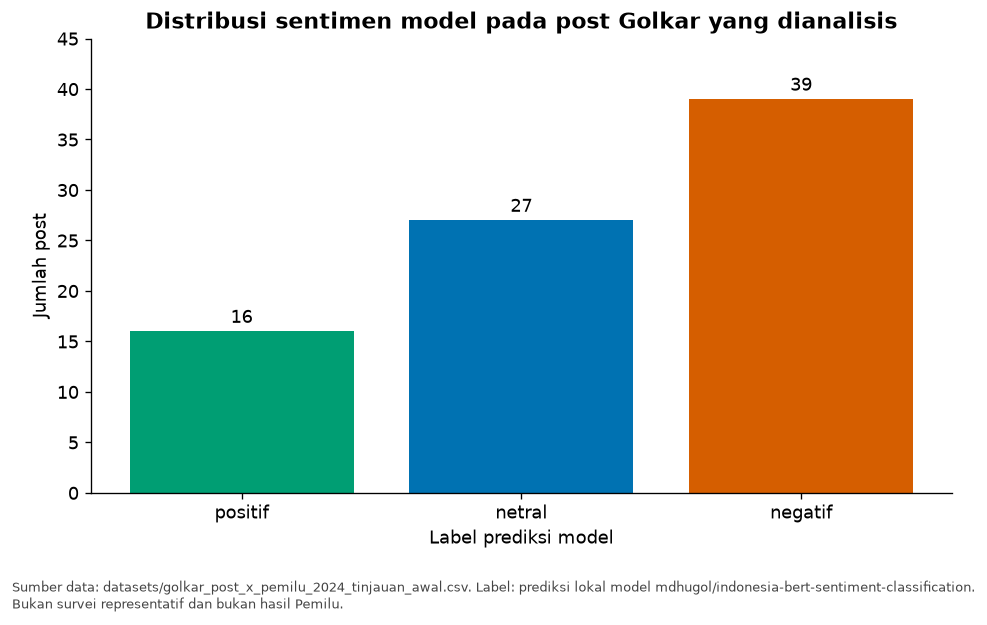

Gambar disimpan: outputs\gambar\06_volume_sentimen_mingguan.png


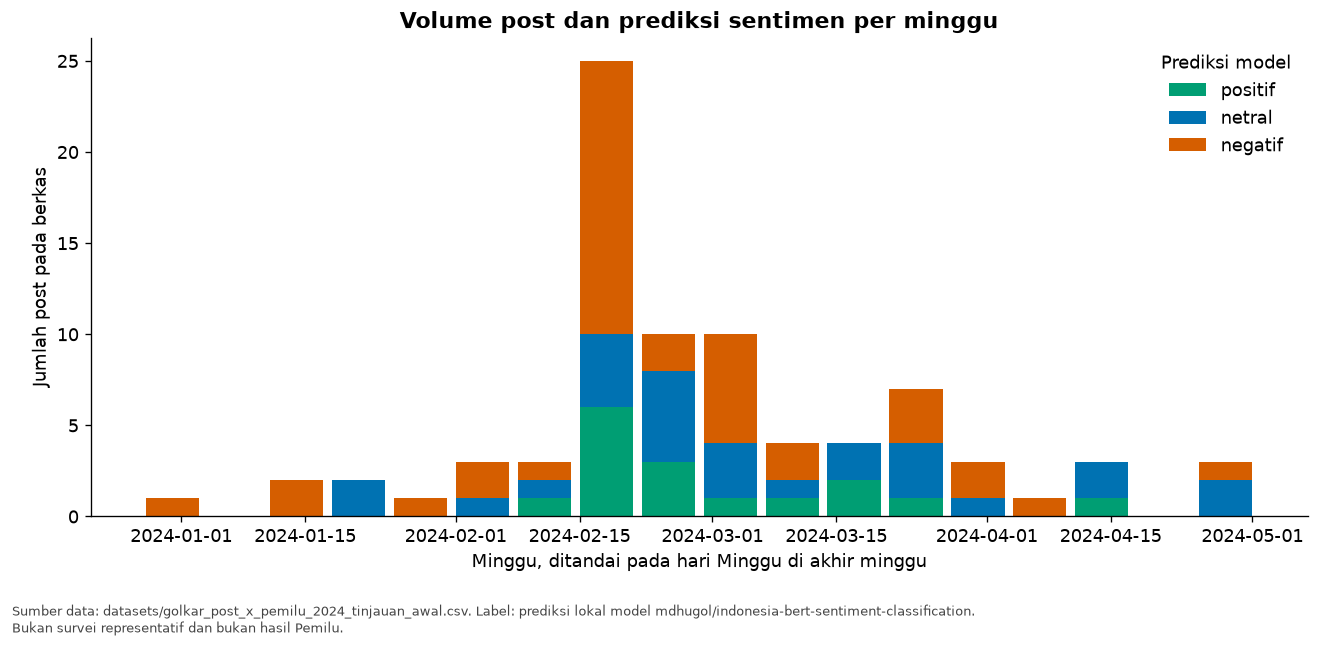

Gambar disimpan: outputs\gambar\08_confidence_model.png


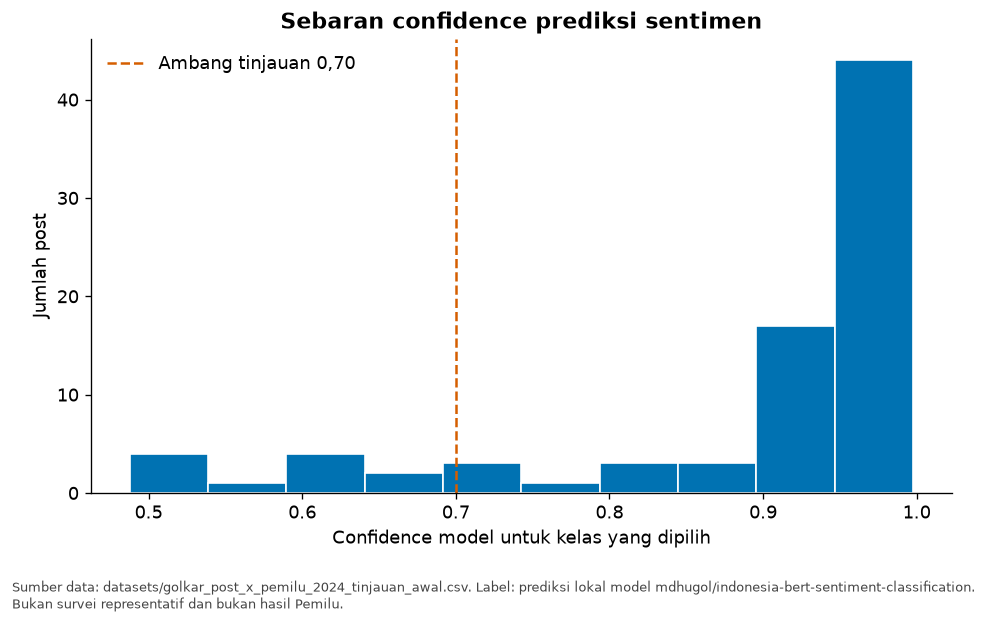

In [13]:
dianalisis = post.loc[post["masuk_analisis_sentimen"]].copy()
dianalisis["confidence_model"] = dianalisis["confidence_model"].astype(float)
urutan_sentimen = ["positif", "netral", "negatif"]
warna_sentimen = {"positif": "#009E73", "netral": "#0072B2", "negatif": "#D55E00"}
CATATAN_POST = (
    "Sumber data: datasets/golkar_post_x_pemilu_2024_tinjauan_awal.csv. "
    "Label: prediksi lokal model mdhugol/indonesia-bert-sentiment-classification.\n"
    "Bukan survei representatif dan bukan hasil Pemilu."
)

hitung = dianalisis["sentimen_model"].value_counts().reindex(urutan_sentimen)
n_analisis = int(len(dianalisis))
n_keluar = int((~post["masuk_analisis_sentimen"]).sum())
n_tinjau = int(dianalisis["perlu_tinjauan_manual"].sum())
n_rendah = int((dianalisis["confidence_model"] < AMBANG_TINJAUAN).sum())

display(Markdown(
    f"Post pada berkas: **{len(post)}**. Masuk prediksi: **{n_analisis}**. "
    f"Dikeluarkan: **{n_keluar}**, karena teksnya ringkasan pengumpul, bukan isi post. "
    f"Dari yang diprediksi, positif {int(hitung['positif'])}, "
    f"netral {int(hitung['netral'])}, negatif {int(hitung['negatif'])}. "
    f"Confidence di bawah 0,70: {n_rendah}. "
    f"Perlu tinjauan manual menurut aturan notebook: {n_tinjau}."
))

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(hitung.index, hitung.values, color=[warna_sentimen[nama] for nama in hitung.index])
for posisi, nilai in enumerate(hitung.values):
    ax.text(posisi, nilai + 0.4, str(int(nilai)), ha="center", va="bottom")
ax.set_ylim(0, hitung.max() + 6)
ax.set_xlabel("Label prediksi model")
ax.set_ylabel("Jumlah post")
ax.set_title("Distribusi sentimen model pada post Golkar yang dianalisis")
fig.text(0.0, -0.02, CATATAN_POST, ha="left", va="top", fontsize=8, color="#444444")
fig.tight_layout()
simpan_gambar(fig, "05_distribusi_sentimen_post_golkar.png")
plt.show()

dianalisis["tanggal"] = pd.to_datetime(dianalisis["tanggal_post"])
mingguan = (
    dianalisis.groupby([pd.Grouper(key="tanggal", freq="W-SUN"), "sentimen_model"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=urutan_sentimen, fill_value=0)
)
fig, ax = plt.subplots(figsize=(11, 5))
bawah = None
for nama in urutan_sentimen:
    ax.bar(
        mingguan.index,
        mingguan[nama],
        bottom=0 if bawah is None else bawah,
        width=6,
        label=nama,
        color=warna_sentimen[nama],
    )
    bawah = mingguan[nama] if bawah is None else bawah + mingguan[nama]
ax.set_xlabel("Minggu, ditandai pada hari Minggu di akhir minggu")
ax.set_ylabel("Jumlah post pada berkas")
ax.set_title("Volume post dan prediksi sentimen per minggu")
ax.legend(title="Prediksi model", frameon=False)
fig.text(0.0, -0.02, CATATAN_POST, ha="left", va="top", fontsize=8, color="#444444")
fig.tight_layout()
simpan_gambar(fig, "06_volume_sentimen_mingguan.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(dianalisis["confidence_model"], bins=10, color="#0072B2", edgecolor="white")
ax.axvline(AMBANG_TINJAUAN, color="#D55E00", linestyle="--", label="Ambang tinjauan 0,70")
ax.set_xlabel("Confidence model untuk kelas yang dipilih")
ax.set_ylabel("Jumlah post")
ax.set_title("Sebaran confidence prediksi sentimen")
ax.legend(frameon=False)
fig.text(0.0, -0.02, CATATAN_POST, ha="left", va="top", fontsize=8, color="#444444")
fig.tight_layout()
simpan_gambar(fig, "08_confidence_model.png")
plt.show()

## 19. Kata yang sering muncul

Hitungan kata memakai huruf kecil hanya untuk menjumlahkan ejaan yang sama. Kata umum seperti `yang`, `dan`, dan `di` disingkirkan. Kata `golkar` juga disingkirkan dari grafik ini karena post pada berkas memang dikumpulkan karena menyebut Golkar. Kalau kata itu dibiarkan, ketiga kelompok akan terlihat sama. Negasi seperti `tidak`, `gak`, dan `nggak` tidak disingkirkan.

Ini frekuensi kata pada teks yang terkumpul, bukan tema resmi dan bukan alasan hasil Pemilu.

Gambar disimpan: outputs\gambar\07_kata_sering_per_sentimen.png


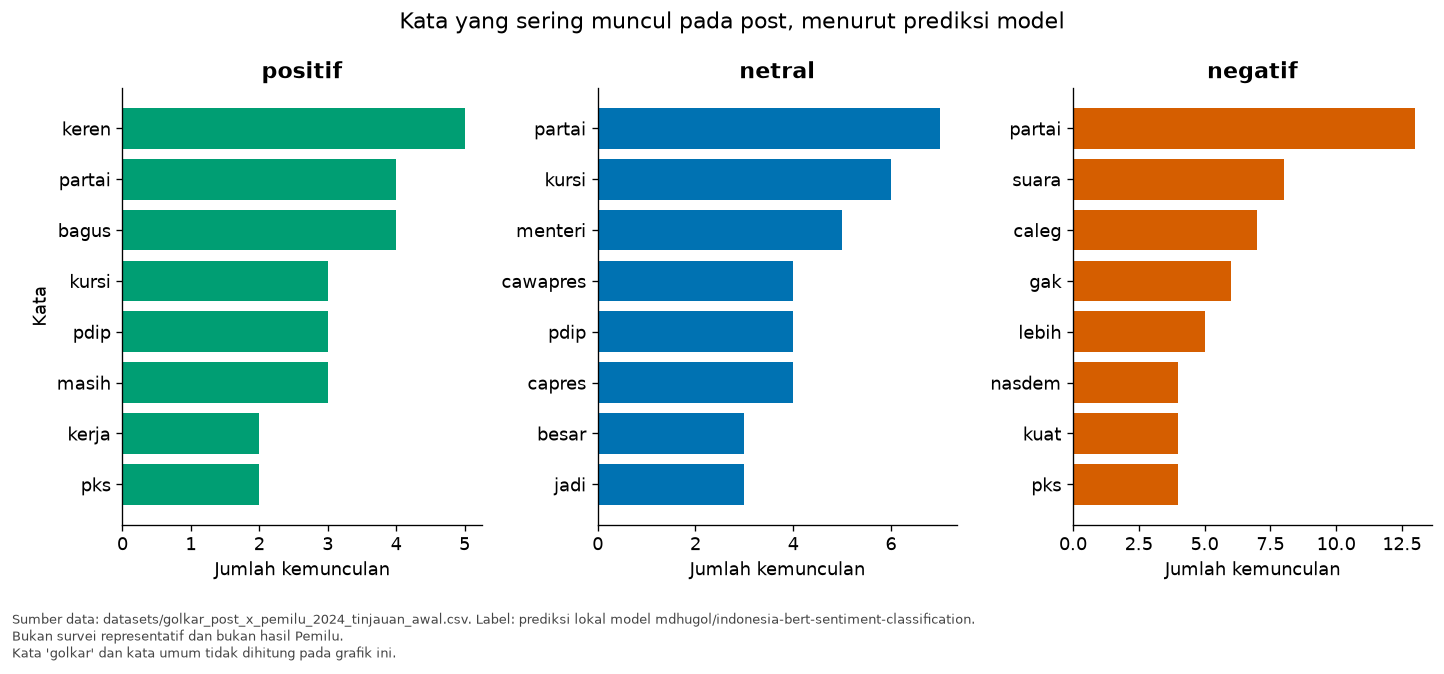

In [14]:
KATA_UMUM = {
    "yang", "dan", "ini", "itu", "dari", "untuk", "dengan", "ada", "atau", "juga",
    "pada", "dalam", "akan", "sudah", "udah", "kalau", "kalo", "karena", "krn", "bisa",
    "saya", "aku", "kita", "mereka", "dia", "nya", "sih", "dong", "deh", "kok",
    "aja", "saja", "tapi", "tetapi", "buat", "bagi", "para", "saat", "banget",
    "the", "and", "that", "this", "golkar",
}


def daftar_kata(teks):
    return [kata for kata in re.findall(r"[A-Za-z]+", str(teks).lower()) if len(kata) >= 3 and kata not in KATA_UMUM]


fig, sumbu = plt.subplots(1, 3, figsize=(12, 5), sharex=False)
for sumbu_satu, nama in zip(sumbu, urutan_sentimen):
    kantong = []
    for teks in dianalisis.loc[dianalisis["sentimen_model"] == nama, "teks_bersih"]:
        kantong.extend(daftar_kata(teks))
    frekuensi = pd.Series(kantong).value_counts().head(8).sort_values()
    sumbu_satu.barh(frekuensi.index, frekuensi.values, color=warna_sentimen[nama])
    sumbu_satu.set_title(nama)
    sumbu_satu.set_xlabel("Jumlah kemunculan")
sumbu[0].set_ylabel("Kata")
fig.suptitle("Kata yang sering muncul pada post, menurut prediksi model", fontsize=13)
fig.text(0.0, -0.02, CATATAN_POST + "\nKata 'golkar' dan kata umum tidak dihitung pada grafik ini.", ha="left", va="top", fontsize=8, color="#444444")
fig.tight_layout()
simpan_gambar(fig, "07_kata_sering_per_sentimen.png")
plt.show()

## Frasa lebih dari satu kata, lalu ringkasan topik

Grafik kata di atas menghitung satu kata. Di bawah ini ada dua hitungan lain. Keduanya tetap memakai 82 post yang masuk prediksi model, bukan label manusia.

**Frasa berulang.** Dua atau tiga kata yang ditulis berdekatan, setelah kata sambung seperti `yang` dan `di` disingkirkan. Negasi tidak dibuang. Hanya frasa yang muncul di sedikitnya dua post yang ditampilkan. Satu post dihitung sekali meskipun frasanya berulang di dalam post itu.

**Topik.** Beberapa frasa yang mirip dikelompokkan dengan aturan yang tertulis di sel berikutnya. Misalnya `kursi DPR`, `jumlah kursi`, dan `18 kursi` masuk kelompok yang sama. Ini pengelompokan notebook, bukan keluaran model dan bukan tema resmi partai. Satu post boleh masuk lebih dari satu topik, jadi jumlah topik tidak dijumlahkan menjadi 82.

CSV frasa dan topik disimpan: outputs\sentimen\frasa_dan_topik_per_sentimen_2024.csv


**Frasa yang tertulis berulang di sedikitnya dua post.** Kosong pada suatu sentimen berarti tidak ada pasangan kata yang dipakai ulang.

,sentimen_model,nama,jumlah_post
8,negatif,pasang foto,2
9,negatif,terlalu kuat,2
4,netral,capres cawapres,3
2,netral,jadi capres,2
3,netral,jadi capres cawapres,2
6,netral,naik suaranya,2
5,netral,partai besar,2
7,netral,serangan fajar,2
0,positif,kerja keras,2
1,positif,masih bagus,2


**Jumlah post per topik.** Satu post dapat terhitung di lebih dari satu baris. Kolom adalah prediksi model, bukan label manusia.

sentimen_model,positif,netral,negatif,jumlah
nama,,,,
suara naik atau suara tinggi,2,3,7,12
caleg dan kampanye,1,3,6,10
kursi DPR,2,3,2,7
capres dan cawapres,0,4,2,6
jatah menteri,0,3,2,5
mesin partai dan kader,3,1,1,5
oposisi atau koalisi,0,1,4,5
orde baru atau serangan fajar,1,2,2,5
perbandingan dengan PDIP,1,1,1,3


Ringkasan topik pada post yang sudah diprediksi:

- Prediksi **positif**: paling sering mesin partai dan kader (3 post), suara naik atau suara tinggi (2 post).
- Prediksi **netral**: paling sering capres dan cawapres (4 post), suara naik atau suara tinggi (3 post).
- Prediksi **negatif**: paling sering suara naik atau suara tinggi (7 post), caleg dan kampanye (6 post).

Ini gambaran isi post yang terkumpul. Bukan penyebab hasil suara, dan bukan sikap seluruh pemilih.

Gambar disimpan: outputs\gambar\09_topik_post_per_sentimen.png


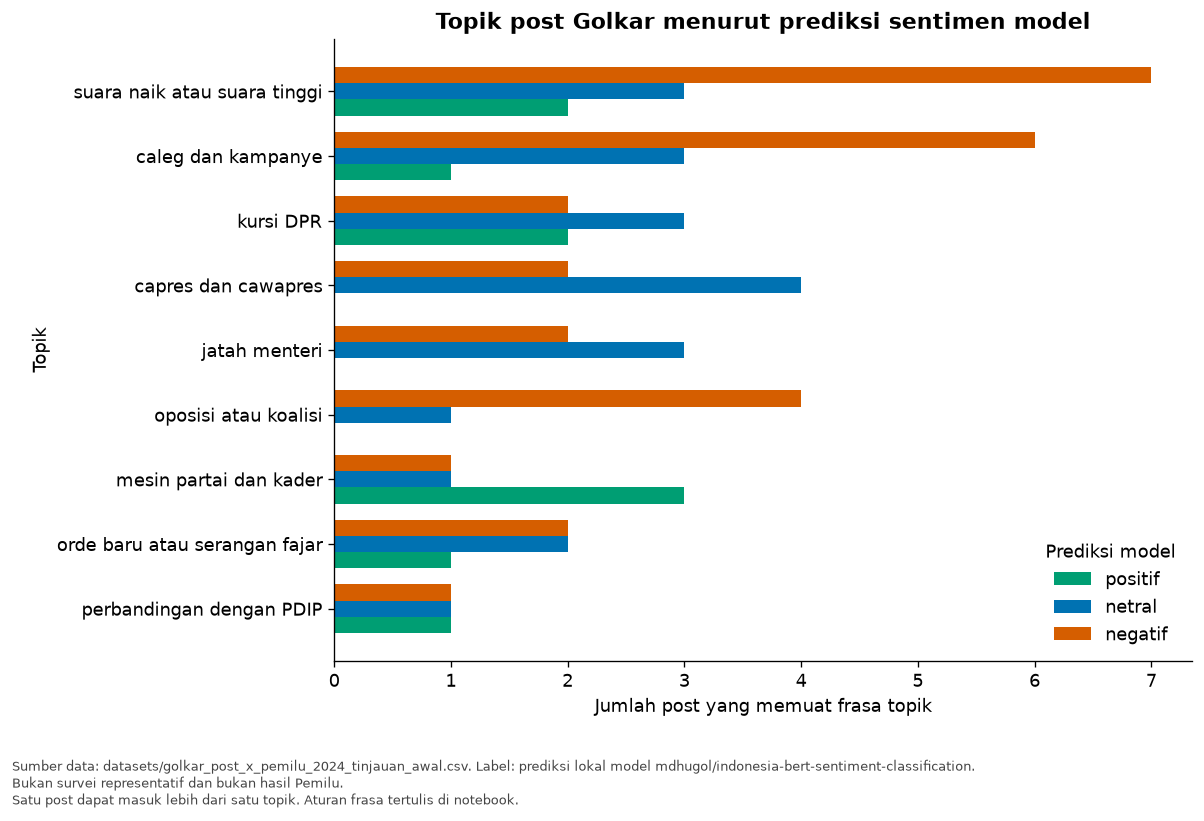

In [15]:

LEKAT = {
    "yg", "dr", "dgn", "dg", "dgn", "sbg", "krn", "utk", "pd", "sy", "aja",
    "ya", "yah", "loh", "lho", "pun", "mah", "kok", "sih", "dong", "deh",
    "atau", "dan", "yang", "dengan", "untuk", "dari", "pada", "dalam",
    "kalau", "kalo", "karena", "tetapi", "tapi", "juga", "sudah", "akan",
}


def teks_normal(teks):
    hasil = str(teks).lower().replace("pdi-p", "pdip").replace("pdi p", "pdip")
    hasil = re.sub(r"[^a-z0-9\s]", " ", hasil)
    hasil = re.sub(r"\s+", " ", hasil).strip()
    return hasil


def kata_isi(teks):
    return [kata for kata in teks_normal(teks).split() if len(kata) >= 3 and kata not in KATA_UMUM and kata not in LEKAT]


def frasa_dalam_post(teks):
    kata = kata_isi(teks)
    himpunan = set()
    for panjang in (2, 3):
        for i in range(len(kata) - panjang + 1):
            himpunan.add(" ".join(kata[i:i + panjang]))
    return himpunan


baris_frasa = []
for nama in urutan_sentimen:
    kumpulan = dianalisis.loc[dianalisis["sentimen_model"] == nama, "teks_bersih"]
    hitung = {}
    contoh = {}
    for teks in kumpulan:
        for frasa in frasa_dalam_post(teks):
            hitung[frasa] = hitung.get(frasa, 0) + 1
            contoh.setdefault(frasa, teks)
    for frasa, jumlah in hitung.items():
        if jumlah >= 2:
            baris_frasa.append({
                "jenis": "frasa_berulang",
                "sentimen_model": nama,
                "nama": frasa,
                "jumlah_post": jumlah,
                "contoh": contoh[frasa],
            })

ATURAN_TOPIK = [
    ("suara naik atau suara tinggi", [
        r"suara\w* naik", r"naik suara\w*", r"suara\w* (lebih )?tinggi",
        r"suara terbanyak", r"suara besar", r"paling tinggi", r"peroleh suara", r"banyak suara",
    ]),
    ("kursi DPR", [
        r"kursi dpr", r"kursi golkar", r"kursi terbanyak", r"jumlah kursi",
        r"banyak kursi", r"kursi di senayan", r"ketua dpr", r"\d+ kursi", r"lebih banyak kursi",
    ]),
    ("perbandingan dengan PDIP", [
        r"pdip.{0,30}(suara|kursi|unggul|menang|naik|nyalip)",
        r"(suara|kursi|unggul|menang|naik|nyalip).{0,30}pdip",
    ]),
    ("capres dan cawapres", [
        r"capres cawapres\w*", r"jadi capres", r"ajukan capres", r"capres atau cawapres",
    ]),
    ("jatah menteri", [
        r"jatah menteri", r"kursi menteri", r"\d+ menteri", r"posisi kabinet", r"minta jatah",
    ]),
    ("mesin partai dan kader", [
        r"mesin partai", r"kerja keras", r"kaderisasi", r"grass ?root", r"jaringan caleg",
    ]),
    ("orde baru atau serangan fajar", [
        r"orde baru", r"\borba\b", r"serangan fajar",
    ]),
    ("oposisi atau koalisi", [
        r"jadi oposisi", r"ikut koalisi", r"\bkoalisi\b", r"\boposisi\b",
    ]),
    ("caleg dan kampanye", [
        r"pasang foto", r"\bcaleg\w*", r"\bbaliho\b",
    ]),
]

baris_topik = []
for nama_topik, pola in ATURAN_TOPIK:
    pola_gabung = re.compile("|".join(f"(?:{pola_satu})" for pola_satu in pola))
    for nama in urutan_sentimen:
        bagian = dianalisis.loc[dianalisis["sentimen_model"] == nama, "teks_bersih"]
        jumlah = 0
        contoh = ""
        kutipan = ""
        for teks in bagian:
            ketemu = pola_gabung.search(teks_normal(teks))
            if ketemu:
                jumlah += 1
                if not contoh:
                    contoh = teks
                    kutipan = ketemu.group(0)
        if jumlah:
            baris_topik.append({
                "jenis": "topik",
                "sentimen_model": nama,
                "nama": nama_topik,
                "jumlah_post": jumlah,
                "contoh": contoh,
                "frasa_yang_cocok": kutipan,
            })

tabel_frasa = pd.DataFrame(baris_frasa)
tabel_topik = pd.DataFrame(baris_topik)
jalur_topik = FOLDER_SENTIMEN / "frasa_dan_topik_per_sentimen_2024.csv"
pd.concat([tabel_frasa, tabel_topik], ignore_index=True).to_csv(jalur_topik, index=False, encoding="utf-8-sig")
print(f"CSV frasa dan topik disimpan: {jalur_topik.relative_to(ROOT)}")

display(Markdown(
    "**Frasa yang tertulis berulang di sedikitnya dua post.** "
    "Kosong pada suatu sentimen berarti tidak ada pasangan kata yang dipakai ulang."
))
if tabel_frasa.empty:
    print("Tidak ada frasa berulang.")
else:
    tampil_frasa = tabel_frasa.sort_values(
        ["sentimen_model", "jumlah_post", "nama"], ascending=[True, False, True]
    )[["sentimen_model", "nama", "jumlah_post"]]
    display(tampil_frasa.head(24))

tabel_topik_lebar = (
    tabel_topik.pivot(index="nama", columns="sentimen_model", values="jumlah_post")
    .reindex(columns=urutan_sentimen)
    .fillna(0)
    .astype(int)
)
tabel_topik_lebar["jumlah"] = tabel_topik_lebar.sum(axis=1)
tabel_topik_lebar = tabel_topik_lebar.sort_values("jumlah", ascending=False)
display(Markdown(
    "**Jumlah post per topik.** Satu post dapat terhitung di lebih dari satu baris. "
    "Kolom adalah prediksi model, bukan label manusia."
))
display(tabel_topik_lebar)

ringkas = []
for nama in urutan_sentimen:
    urut = tabel_topik.loc[tabel_topik["sentimen_model"] == nama].sort_values("jumlah_post", ascending=False)
    dua = ", ".join(f"{baris.nama} ({int(baris.jumlah_post)} post)" for baris in urut.head(2).itertuples())
    ringkas.append(f"- Prediksi **{nama}**: paling sering {dua}.")
display(Markdown(
    "Ringkasan topik pada post yang sudah diprediksi:\n\n" + "\n".join(ringkas) +
    "\n\nIni gambaran isi post yang terkumpul. Bukan penyebab hasil suara, dan bukan sikap seluruh pemilih."
))

gambar = tabel_topik_lebar.sort_values("jumlah", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6.2))
posisi = list(range(len(gambar)))
tinggi = 0.25
for geser, nama in enumerate(urutan_sentimen):
    y = [nilai + (geser - 1) * tinggi for nilai in posisi]
    ax.barh(y, gambar[nama], height=tinggi, color=warna_sentimen[nama], label=nama)
ax.set_yticks(posisi)
ax.set_yticklabels(gambar.index)
ax.set_xlabel("Jumlah post yang memuat frasa topik")
ax.set_ylabel("Topik")
ax.set_title("Topik post Golkar menurut prediksi sentimen model")
ax.legend(title="Prediksi model", frameon=False)
fig.text(
    0.0, -0.03,
    CATATAN_POST + "\nSatu post dapat masuk lebih dari satu topik. Aturan frasa tertulis di notebook.",
    ha="left", va="top", fontsize=8, color="#444444",
)
fig.tight_layout()
simpan_gambar(fig, "09_topik_post_per_sentimen.png")
plt.show()


## 20. Contoh post dan tinjauan manual

Contoh di tabel pertama adalah post dengan confidence tertinggi pada tiap kelas. Itu contoh cara model membaca teks, bukan bukti bahwa labelnya benar.

Tinjauan di bawah dilakukan dengan membaca teksnya. Tidak ada label pengganti yang ditulis. Confidence tinggi tetap bukan kebenaran.

- `GX2024-010` memakai kata `keren` dan menyebut posisi elektoral. Model memberi positif dengan confidence sangat tinggi. Kata sikapnya eksplisit, tetapi ini tetap prediksi.
- `GX2024-017` memakai kata `menyedihkan`. Model memberi negatif dengan confidence sangat tinggi. Sama seperti di atas: prediksi, bukan fakta sikap publik.
- `GX2024-067` membahas jatah kursi menteri. Model memberi netral dengan confidence sangat tinggi. Kalimat politik yang keras bisa tetap berlabel netral. Confidence tinggi tidak otomatis sama dengan pembacaan manusia.
- `GX2024-080` membuka dengan kata `Hebat`, lalu beralih ke kritik yang terpotong. Model memberi netral dengan confidence rendah. Cuplikan ini mudah terbaca sebagai sindiran. Notebook tidak mengganti labelnya.
- `GX2024-062` memakai `berani` dan `hehe`. Itu bisa pujian atau sindiran. Confidence model rendah.
- `GX2024-055` dan `GX2024-052` membandingkan suara dan kursi. Isinya lebih dekat ke hitungan politik daripada pujian atau cacian. Confidence rendah.
- `GX2024-004` memakai `terpaksa` dan emoji. Confidence-nya berada di atas 0,70, tetapi nada politiknya tetap bercampur. Karena itu emoji masuk alasan tinjauan walaupun ambang confidence terlewati.

In [16]:
id_tinjauan = [
    "GX2024-010", "GX2024-017", "GX2024-067",
    "GX2024-080", "GX2024-062", "GX2024-055", "GX2024-052", "GX2024-004",
]
tinjauan = post.loc[post["record_id"].isin(id_tinjauan), [
    "record_id", "sentimen_model", "confidence_model", "status_kualitas_sumber",
    "perlu_tinjauan_manual", "alasan_tinjauan", "url_post", "teks_bersih",
]].copy()
tinjauan["confidence_model"] = tinjauan["confidence_model"].astype(float).round(3)
tinjauan["urutan"] = tinjauan["record_id"].map({kode: urut for urut, kode in enumerate(id_tinjauan)})
tinjauan = tinjauan.sort_values("urutan").drop(columns="urutan")
if len(tinjauan) != len(id_tinjauan):
    raise AssertionError("Sebagian ID tinjauan manual tidak ada pada berkas.")
display(tinjauan)

contoh = []
for nama in urutan_sentimen:
    bagian = dianalisis.loc[dianalisis["sentimen_model"] == nama]
    contoh.append(bagian.nlargest(1, "confidence_model").iloc[0])
tabel_contoh = pd.DataFrame(contoh)[[
    "record_id", "sentimen_model", "confidence_model", "url_post", "teks_bersih",
]]
tabel_contoh["confidence_model"] = tabel_contoh["confidence_model"].round(3)
display(Markdown("**Confidence tertinggi pada tiap kelas.**"))
display(tabel_contoh)

,record_id,sentimen_model,confidence_model,status_kualitas_sumber,perlu_tinjauan_manual,alasan_tinjauan,url_post,teks_bersih
9,GX2024-010,positif,0.995,belum_diverifikasi_terhadap_post_asli,False,,https://x.com/DianDrianto/status/1755854346175...,Golkar itu keren juga ya.. Walaupun seakan nda...
16,GX2024-017,negatif,0.998,belum_diverifikasi_terhadap_post_asli,False,,https://x.com/judginganalyst/status/1757723620...,Sekarang Golkar ikut koalisi bukan sebagai lea...
66,GX2024-067,netral,0.997,cuplikan_tampak_terpotong_perlu_konteks,True,cuplikan terpotong,https://x.com/NenkMonica/status/17694669106248...,partai ini sdh mematok jatah Kursi Menteri. Go...
79,GX2024-080,netral,0.488,cuplikan_tampak_terpotong_perlu_konteks,True,"confidence di bawah 0,70; cuplikan terpotong",https://x.com/ariefrasyad/status/1777599589220...,"Hebat Golkar, jatidiri asli nya semasa ORBA ke..."
61,GX2024-062,positif,0.503,belum_diverifikasi_terhadap_post_asli,True,"confidence di bawah 0,70",https://x.com/syaithannn/status/17674906141098...,Golkar udah mulai berani. Perolehan kursi terb...
54,GX2024-055,negatif,0.508,belum_diverifikasi_terhadap_post_asli,True,"confidence di bawah 0,70",https://x.com/JokoHQ/status/1763432069127160139,PDIP menang cm dalam hal suara terbanyak. Tp s...
51,GX2024-052,netral,0.621,belum_diverifikasi_terhadap_post_asli,True,"confidence di bawah 0,70",https://x.com/EAAANNH/status/1762849260029239586,Tertinggi suara itu blm tentu linier dg jumlah...
3,GX2024-004,netral,0.724,belum_diverifikasi_terhadap_post_asli,True,ada emoji,https://x.com/ibnoe45/status/1747419415136911363,"Lihat baliho PAN, Golkar dan Demokrat sepanjan..."


**Confidence tertinggi pada tiap kelas.**

,record_id,sentimen_model,confidence_model,url_post,teks_bersih
9,GX2024-010,positif,0.995,https://x.com/DianDrianto/status/1755854346175...,Golkar itu keren juga ya.. Walaupun seakan nda...
66,GX2024-067,netral,0.997,https://x.com/NenkMonica/status/17694669106248...,partai ini sdh mematok jatah Kursi Menteri. Go...
16,GX2024-017,negatif,0.998,https://x.com/judginganalyst/status/1757723620...,Sekarang Golkar ikut koalisi bukan sebagai lea...


## 21. Konteks suara, tanpa digabung dengan sentimen

Angka suara di bawah dibaca lagi dari berkas KPU yang sama dengan bagian pertama. Angka itu hanya konteks. Post pada berkas X tidak punya kolom provinsi, jadi tidak bisa diletakkan di samping pangsa Golkar per provinsi.

Tidak ada kesimpulan bahwa sentimen menyebabkan suara, atau bahwa jumlah post mewakili jumlah pemilih. Orang yang menulis di X pada berkas ini bukan sampel pemilih Indonesia.

In [17]:
if "provinsi" in post.columns:
    raise AssertionError("Berkas post ternyata memuat provinsi. Jangan menggabungkannya ke suara tanpa aturan baru.")

nasional_post = pd.read_csv(DATA / "kpu_suara_nasional_pemilu_2024.csv")
total_nasional_post = int(nasional_post["total_suara_sah_nasional"].iloc[0])
urut_nasional = nasional_post.sort_values("suara_sah_nasional", ascending=False).reset_index(drop=True)
golkar_nasional = urut_nasional.loc[urut_nasional["nama_partai"] == "Partai Golongan Karya"].iloc[0]
peringkat_golkar_nasional = int(urut_nasional.index[urut_nasional["nama_partai"] == "Partai Golongan Karya"][0]) + 1
display(Markdown(
    f"Menurut berkas Keputusan KPU Nomor 1204 Tahun 2024, Golkar memperoleh "
    f"**{fmt_suara(golkar_nasional.suara_sah_nasional)}** suara sah DPR RI, "
    f"peringkat {peringkat_golkar_nasional} dari {len(urut_nasional)} partai. "
    f"Pangsa nasional hitungan notebook: "
    f"{fmt_persen(golkar_nasional.suara_sah_nasional / total_nasional_post * 100, 2)}. "
    f"Post yang diprediksi pada bagian ini berjumlah {n_analisis}. "
    "Dua angka itu tidak dibagi, tidak dikalikan, dan tidak dibandingkan sebagai sebab-akibat."
))

Menurut berkas Keputusan KPU Nomor 1204 Tahun 2024, Golkar memperoleh **23.208.488** suara sah DPR RI, peringkat 2 dari 18 partai. Pangsa nasional hitungan notebook: 15,29%. Post yang diprediksi pada bagian ini berjumlah 82. Dua angka itu tidak dibagi, tidak dikalikan, dan tidak dibandingkan sebagai sebab-akibat.

## 22. Batas hasil sentimen

Yang dapat dikatakan:

- Berkas sumber berisi 85 post yang sudah terkumpul, dengan ID dan URL unik, dari 25 Desember 2023 sampai 28 April 2024.
- Tiga baris adalah ringkasan pengumpul dan tidak diprediksi. Delapan puluh dua baris lainnya diprediksi oleh model lokal.
- Prediksi terbagi menjadi positif, netral, dan negatif. Sebagian perlu dibaca manusia karena confidence rendah, teks terpotong, emoji, atau tuduhan yang belum diverifikasi.
- Kata yang sering muncul berbeda antar kelompok prediksi, setelah kata umum dan kata `golkar` disingkirkan dari hitungan.

Yang tidak dapat dikatakan:

- Akurasi model. Tidak ada label manusia yang sudah diverifikasi.
- Sentimen seluruh pengguna X, seluruh pemilih, atau seluruh masyarakat.
- Hubungan sebab antara isi post dan hasil suara Golkar.
- Benar atau salahnya tuduhan yang tertulis pada sebagian post.

Dataset sumber di `datasets/` dan CSV suara di bagian 1–13 tidak ditimpa. Keluaran baru:

- `outputs/sentimen/golkar_post_x_bersih_2024.csv`
- `outputs/sentimen/golkar_post_x_prediksi_sentimen_2024.csv`
- `outputs/gambar/05_distribusi_sentimen_post_golkar.png`
- `outputs/gambar/06_volume_sentimen_mingguan.png`
- `outputs/gambar/07_kata_sering_per_sentimen.png`
- `outputs/gambar/09_topik_post_per_sentimen.png`
- `outputs/sentimen/frasa_dan_topik_per_sentimen_2024.csv`
- `outputs/gambar/08_confidence_model.png`

Frasa dua atau tiga kata dan kelompok topik dihitung dari teks yang sama. Kelompok topik adalah aturan di notebook. Satu post dapat masuk lebih dari satu topik.

## 23. Kesimpulan

Sel ini merangkum dua bagian notebook. Angka diambil dari hitungan di sel sebelumnya, bukan diketik ulang. Suara dan sentimen tetap dipisah.

In [18]:
jumlah_sentimen = dianalisis["sentimen_model"].value_counts()

puncak_suara = ", ".join(
    f"{baris.provinsi} ({fmt_suara(baris.suara_sah_partai_dpr_ri)} suara, {fmt_persen_sumber(baris.persentase_dari_suara_sah_provinsi)}, peringkat {int(baris.peringkat_suara_di_provinsi)})"
    for baris in tiga_suara_tertinggi.itertuples()
)
puncak_pangsa = ", ".join(
    f"{baris.provinsi} ({fmt_persen_sumber(baris.persentase_dari_suara_sah_provinsi)}, {fmt_suara(baris.suara_sah_partai_dpr_ri)} suara)"
    for baris in tiga_persen_tertinggi.itertuples()
)
kalimat_topik = []
for nama in urutan_sentimen:
    urut = tabel_topik.loc[tabel_topik["sentimen_model"] == nama].sort_values("jumlah_post", ascending=False)
    dua = " dan ".join(f"{baris.nama} ({int(baris.jumlah_post)} post)" for baris in urut.head(2).itertuples())
    kalimat_topik.append(f"{nama}: {dua}")

display(Markdown(f"""
### Pemeriksaan

Berkas suara lulus pemeriksaan. Ada {n_provinsi} provinsi dan 18 partai di setiap provinsi. Jumlah suara partai sama dengan total provinsi, dan jumlah nasional tiap partai sama dengan Keputusan KPU Nomor 1204 Tahun 2024. Tidak ada selisih suara. Sisa pada jumlah persentase berasal dari pembulatan empat desimal.

Berkas post berisi {len(post)} baris. ID dan URL unik. Tiga baris ringkasan pengumpul dikeluarkan dari prediksi. Aturan bersih URL dan mention tidak mengubah teks, karena unsur itu tidak ada di dalam post.

### Hasil suara Golkar

Golkar memperoleh {fmt_suara(total_suara_golkar)} suara sah, atau {fmt_persen(pangsa_nasional_golkar, 2)} dari {fmt_suara(total_suara_nasional)}. Itu peringkat {peringkat_nasional_golkar} nasional, di belakang PDI-P dan di depan Gerindra. Golkar suara terbanyak di {jumlah_peringkat_1} dari {n_provinsi} provinsi. PDI-P tetap lebih besar pada jumlah suara nasional.

Suara Golkar terbanyak: {puncak_suara}. Pangsa tertinggi: {puncak_pangsa}. Jawa Barat punya jauh lebih banyak suara Golkar daripada Papua Barat Daya, tetapi pangsanya lebih rendah. Jumlah suara dan pangsa suara menjawab pertanyaan yang berbeda. Peringkat pertama berarti suara terbanyak, bukan mayoritas.

### Sentimen pada post yang terkumpul

Model `mdhugol/indonesia-bert-sentiment-classification` dijalankan lokal pada {n_analisis} post. Hasilnya {int(jumlah_sentimen['positif'])} positif, {int(jumlah_sentimen['netral'])} netral, dan {int(jumlah_sentimen['negatif'])} negatif. {n_keluar} baris tidak diklasifikasikan karena bukan teks post. {n_rendah} prediksi punya confidence di bawah 0,70. {n_tinjau} post ditandai untuk dibaca manusia.

Topik yang paling sering pada tiap prediksi: {"; ".join(kalimat_topik)}. Satu post dapat masuk lebih dari satu topik. Post berlabel negatif lebih sering membahas suara dan caleg atau kampanye. Post berlabel positif lebih sering membahas mesin partai dan kader. Post berlabel netral lebih sering membahas capres dan cawapres. Label itu prediksi model, bukan penilaian akhir.

### Yang tidak disimpulkan

Sentimen pada {n_analisis} post ini tidak mewakili pengguna X, pemilih, atau masyarakat. Berkas post tidak punya kolom provinsi, jadi tidak disejajarkan dengan suara per provinsi. Jumlah post tidak dibandingkan dengan jumlah suara. Tidak ada label manusia yang terverifikasi, jadi akurasi model tidak dihitung. Pola suara dan isi post dideskripsikan berdampingan. Keduanya tidak dijadikan sebab-akibat.
"""))



### Pemeriksaan

Berkas suara lulus pemeriksaan. Ada 38 provinsi dan 18 partai di setiap provinsi. Jumlah suara partai sama dengan total provinsi, dan jumlah nasional tiap partai sama dengan Keputusan KPU Nomor 1204 Tahun 2024. Tidak ada selisih suara. Sisa pada jumlah persentase berasal dari pembulatan empat desimal.

Berkas post berisi 85 baris. ID dan URL unik. Tiga baris ringkasan pengumpul dikeluarkan dari prediksi. Aturan bersih URL dan mention tidak mengubah teks, karena unsur itu tidak ada di dalam post.

### Hasil suara Golkar

Golkar memperoleh 23.208.488 suara sah, atau 15,29% dari 151.793.293. Itu peringkat 2 nasional, di belakang PDI-P dan di depan Gerindra. Golkar suara terbanyak di 14 dari 38 provinsi. PDI-P tetap lebih besar pada jumlah suara nasional.

Suara Golkar terbanyak: Jawa Barat (4.292.082 suara, 16,3250%, peringkat 1), Jawa Timur (3.232.091 suara, 13,7280%, peringkat 4), Jawa Tengah (2.648.583 suara, 12,6454%, peringkat 3). Pangsa tertinggi: Papua Barat Daya (30,2287%, 102.786 suara), Papua Barat (29,8640%, 95.883 suara), Bengkulu (28,1832%, 324.563 suara). Jawa Barat punya jauh lebih banyak suara Golkar daripada Papua Barat Daya, tetapi pangsanya lebih rendah. Jumlah suara dan pangsa suara menjawab pertanyaan yang berbeda. Peringkat pertama berarti suara terbanyak, bukan mayoritas.

### Sentimen pada post yang terkumpul

Model `mdhugol/indonesia-bert-sentiment-classification` dijalankan lokal pada 82 post. Hasilnya 16 positif, 27 netral, dan 39 negatif. 3 baris tidak diklasifikasikan karena bukan teks post. 11 prediksi punya confidence di bawah 0,70. 32 post ditandai untuk dibaca manusia.

Topik yang paling sering pada tiap prediksi: positif: mesin partai dan kader (3 post) dan suara naik atau suara tinggi (2 post); netral: capres dan cawapres (4 post) dan suara naik atau suara tinggi (3 post); negatif: suara naik atau suara tinggi (7 post) dan caleg dan kampanye (6 post). Satu post dapat masuk lebih dari satu topik. Post berlabel negatif lebih sering membahas suara dan caleg atau kampanye. Post berlabel positif lebih sering membahas mesin partai dan kader. Post berlabel netral lebih sering membahas capres dan cawapres. Label itu prediksi model, bukan penilaian akhir.

### Yang tidak disimpulkan

Sentimen pada 82 post ini tidak mewakili pengguna X, pemilih, atau masyarakat. Berkas post tidak punya kolom provinsi, jadi tidak disejajarkan dengan suara per provinsi. Jumlah post tidak dibandingkan dengan jumlah suara. Tidak ada label manusia yang terverifikasi, jadi akurasi model tidak dihitung. Pola suara dan isi post dideskripsikan berdampingan. Keduanya tidak dijadikan sebab-akibat.
